In [1]:
!pip install rdkit

Maximum SMILES length: 28
Number of unique characters: 18
OHE Matrix Shape: (133885, 504)
Fixed Test Samples: 24869

Training Fraction = 15%
Training Samples = 16352


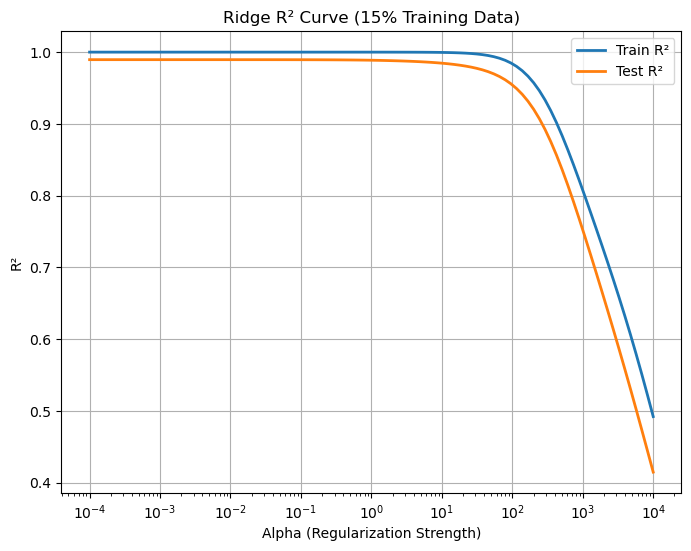

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999987081752828

Results
----------------------------------------
Train MSE : 0.0008
Train R²  : 1.0000
Train RMSE : 0.0287
Test MSE  : 60.8082
Test R²   : 0.9895
Test RMSE  : 7.7980


<Figure size 800x800 with 0 Axes>

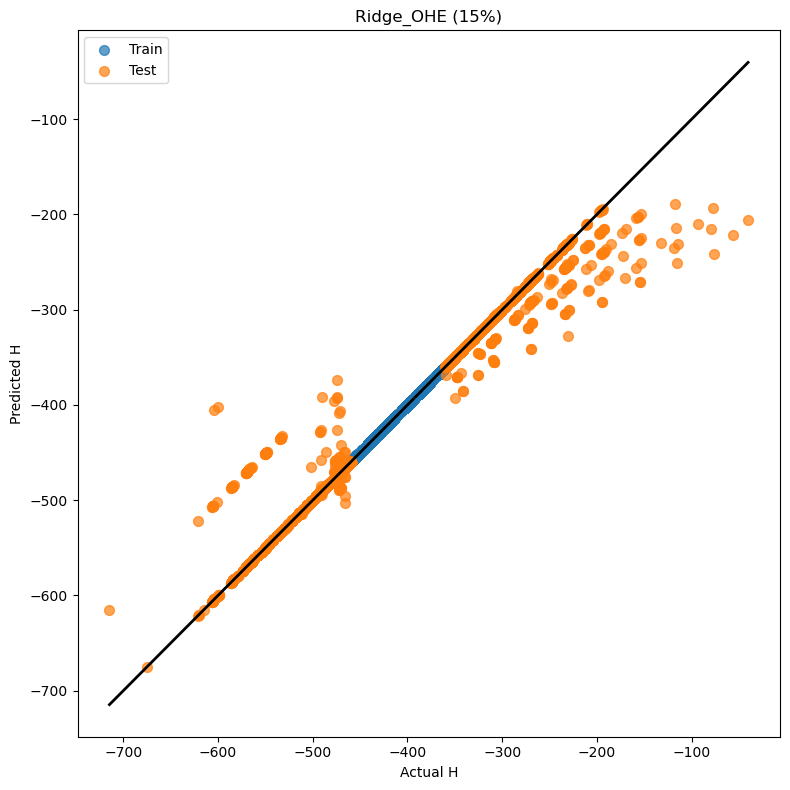


Training Fraction = 30%
Training Samples = 32704


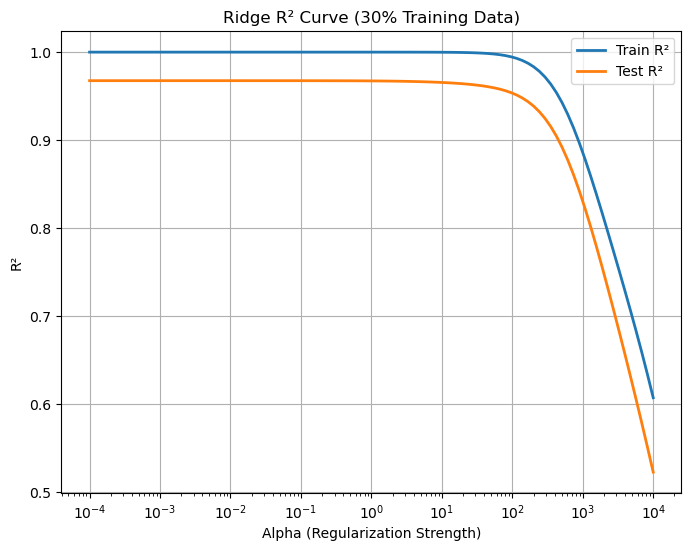

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999983864270173

Results
----------------------------------------
Train MSE : 0.0010
Train R²  : 1.0000
Train RMSE : 0.0322
Test MSE  : 188.0384
Test R²   : 0.9675
Test RMSE  : 13.7127


<Figure size 800x800 with 0 Axes>

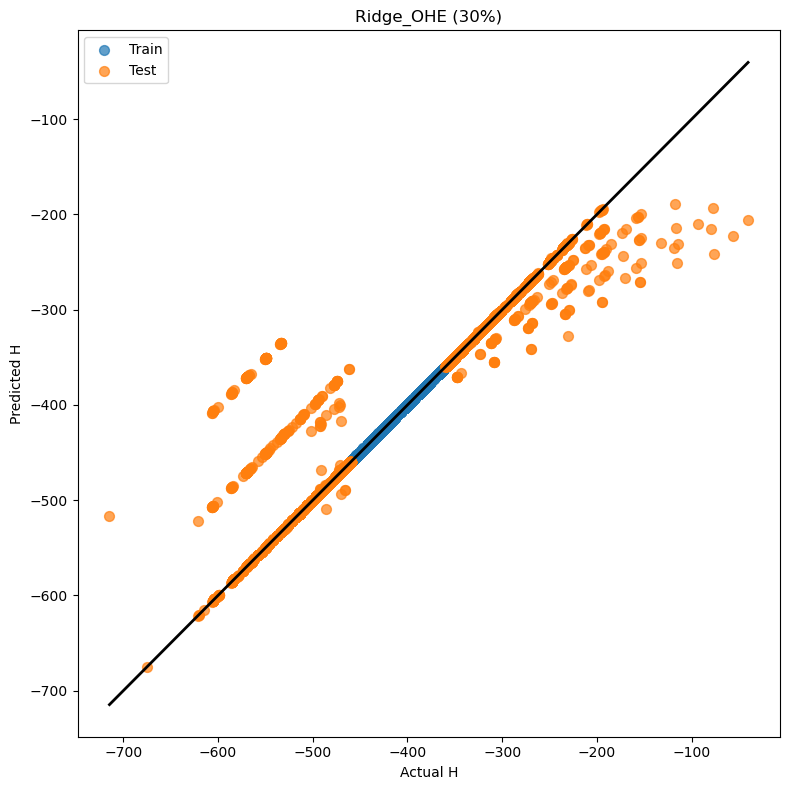


Training Fraction = 45%
Training Samples = 49057


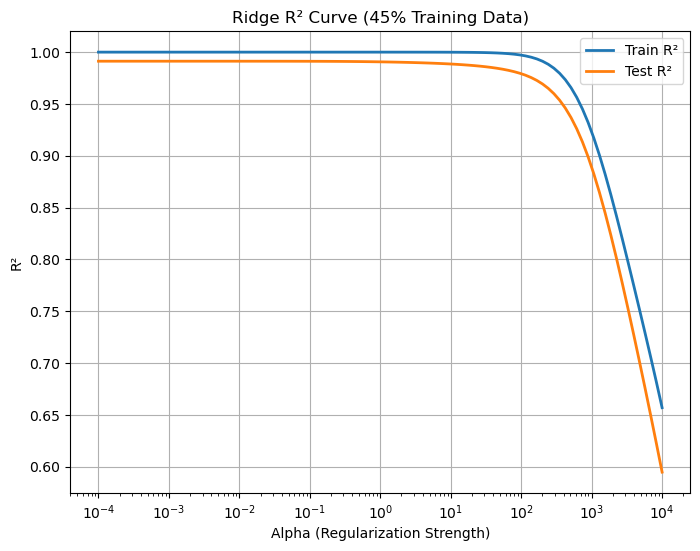

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999984407561995

Results
----------------------------------------
Train MSE : 0.0010
Train R²  : 1.0000
Train RMSE : 0.0317
Test MSE  : 50.7256
Test R²   : 0.9912
Test RMSE  : 7.1222


<Figure size 800x800 with 0 Axes>

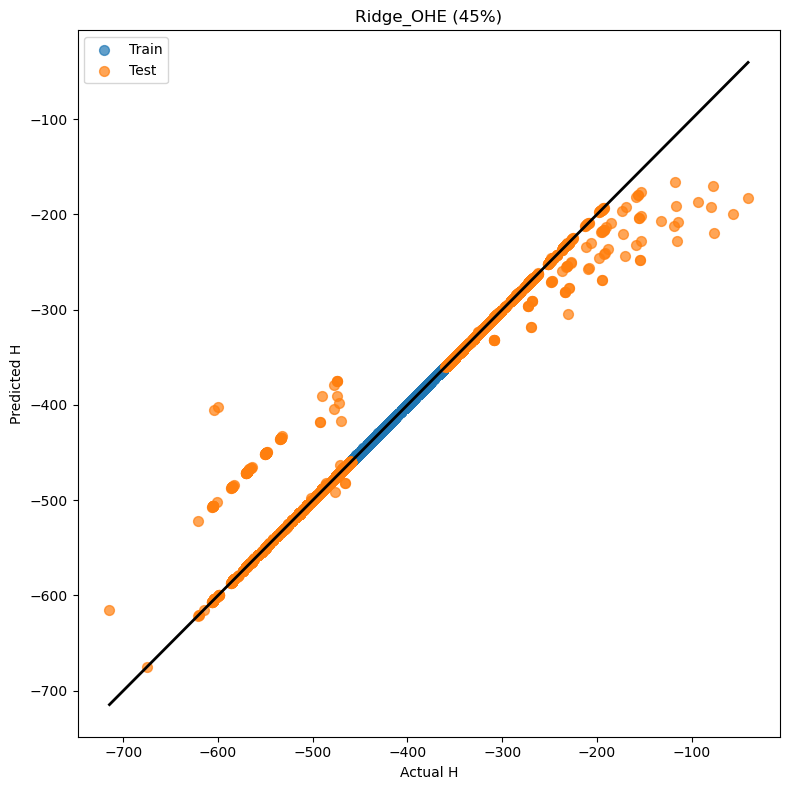


Training Fraction = 60%
Training Samples = 65409


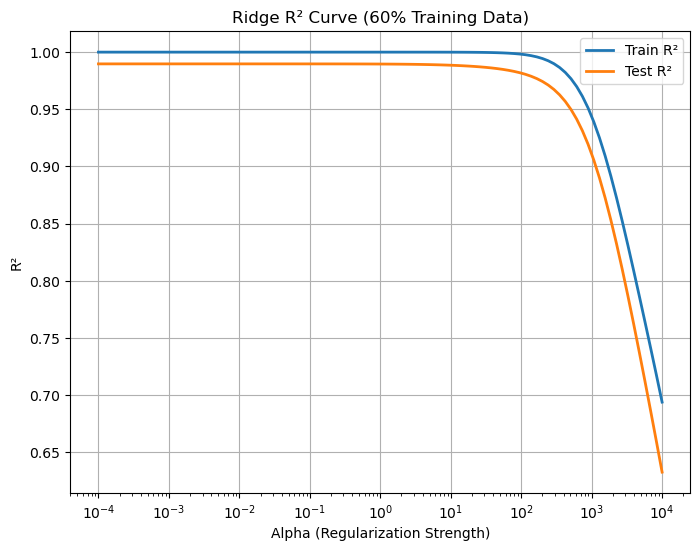

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999984434723025

Results
----------------------------------------
Train MSE : 0.0010
Train R²  : 1.0000
Train RMSE : 0.0316
Test MSE  : 59.5593
Test R²   : 0.9897
Test RMSE  : 7.7175


<Figure size 800x800 with 0 Axes>

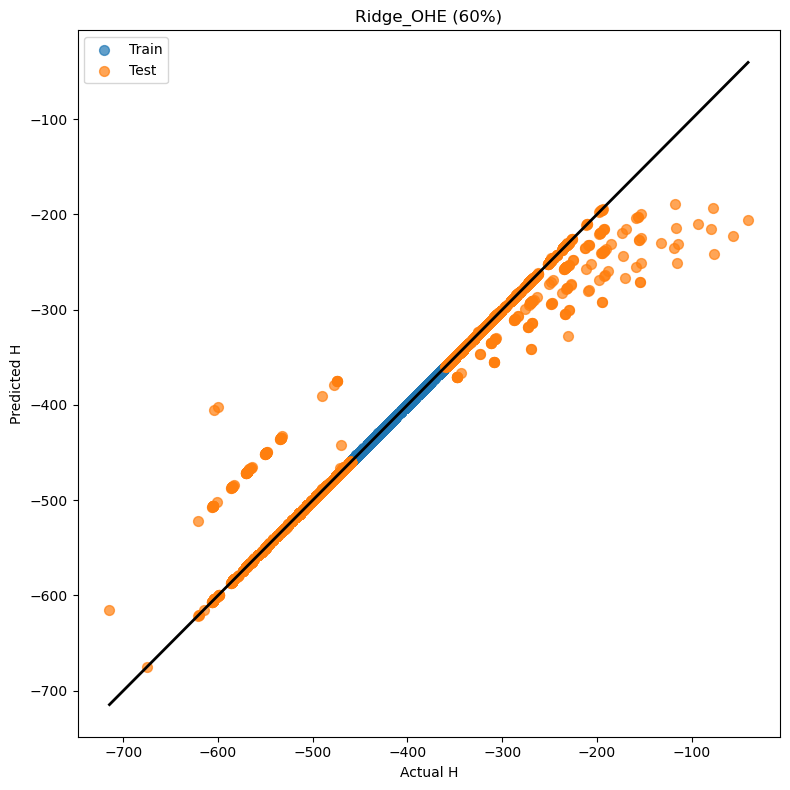


Training Fraction = 75%
Training Samples = 81762


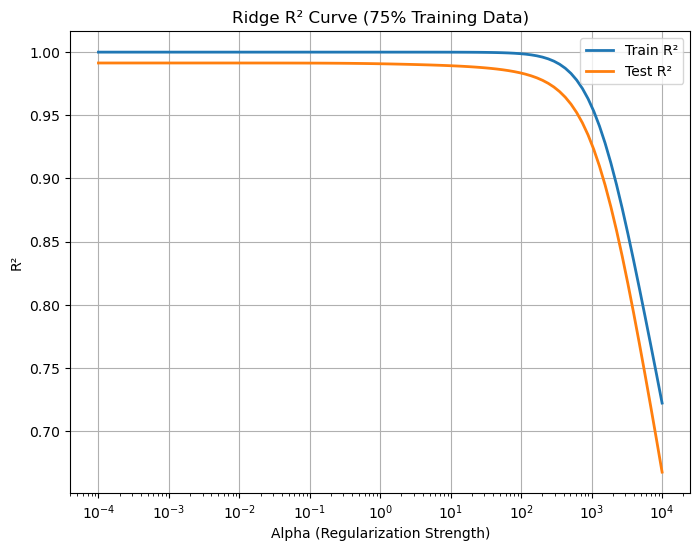

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999984253291266

Results
----------------------------------------
Train MSE : 0.0010
Train R²  : 1.0000
Train RMSE : 0.0318
Test MSE  : 49.8178
Test R²   : 0.9914
Test RMSE  : 7.0582


<Figure size 800x800 with 0 Axes>

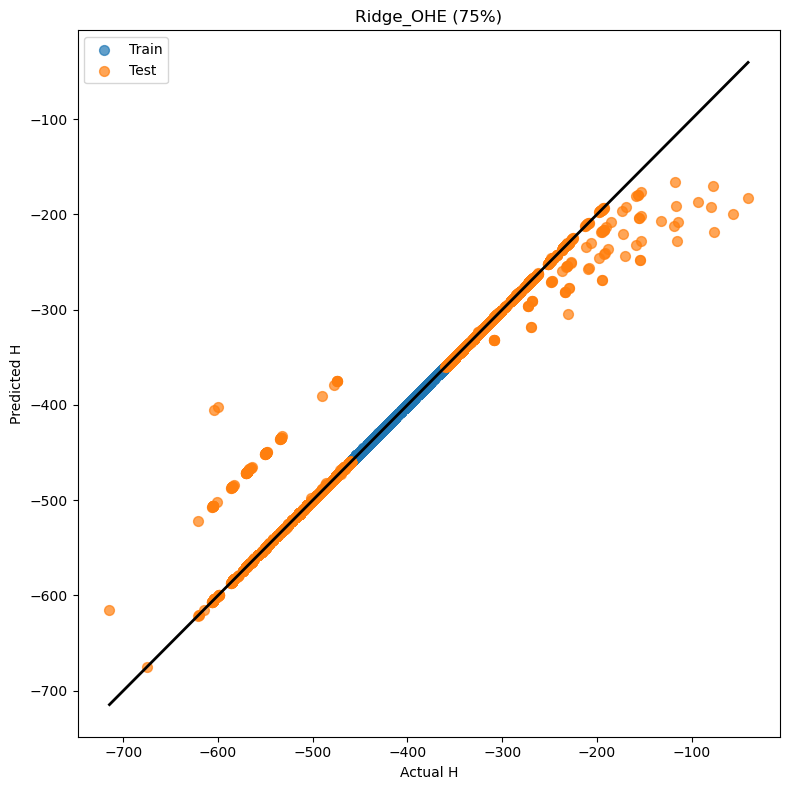


Training Fraction = 90%
Training Samples = 98114


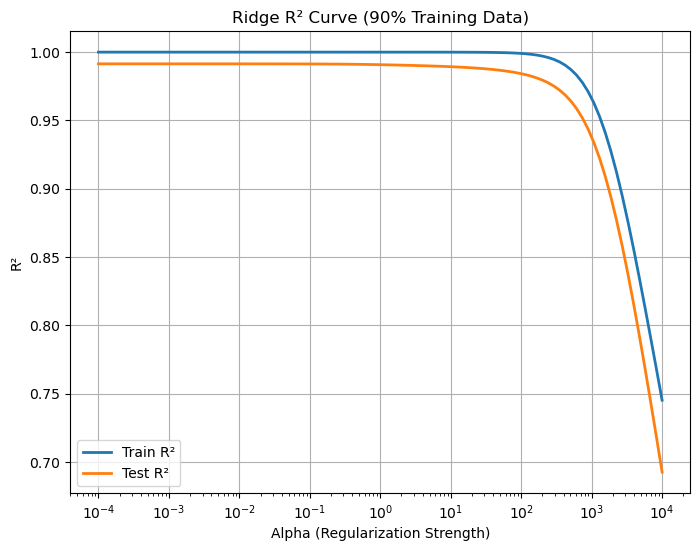

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999764520633865

Results
----------------------------------------
Train MSE : 0.0151
Train R²  : 1.0000
Train RMSE : 0.1230
Test MSE  : 49.8540
Test R²   : 0.9914
Test RMSE  : 7.0607


<Figure size 800x800 with 0 Axes>

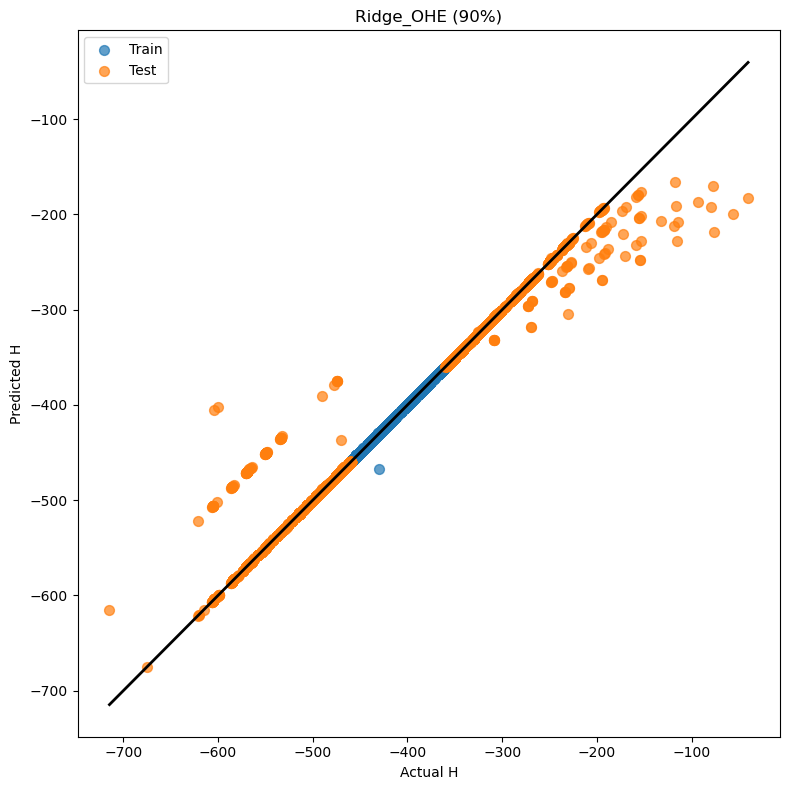

In [2]:
############################################################
# OHE-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"].values
y = data["H"].values
# ===============================
# ONE-HOT ENCODING OF SMILES
# ===============================

# Character vocabulary
all_chars = sorted(set(''.join(smiles)))
char_to_int = {c:i for i,c in enumerate(all_chars)}

max_len = max(len(sm) for sm in smiles)
n_chars = len(all_chars)

print("Maximum SMILES length:", max_len)
print("Number of unique characters:", n_chars)

# Convert SMILES to OHE vectors
X = np.zeros((len(smiles), max_len * n_chars), dtype=np.uint8)

for i, sm in enumerate(smiles):
    for j, ch in enumerate(sm):
        X[i, j*n_chars + char_to_int[ch]] = 1

print("OHE Matrix Shape:", X.shape)

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]

# ===============================
# FIX TEST SET TO 24,869 SAMPLES
# ===============================

np.random.seed(42)

test_indices = np.random.choice(
    len(X_test_all),
    size=24869,
    replace=False
)

X_test = X_test_all[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Samples:", len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

# Alpha values (iterations equivalent)
alpha_values = np.logspace(-4, 4, 100)

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )

    X_train_sub = X_train_full[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    # ===============================
    # SCALING
    # ===============================

    x_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_sub)
    X_test_scaled = x_scaler.transform(X_test)

    # ===============================
    # RIDGE REGRESSION
    # ===============================

    train_r2_list = []
    test_r2_list = []

    for alpha in alpha_values:

        ridge = Ridge(alpha=alpha)

        ridge.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = ridge.predict(X_train_scaled)
        y_pred_test_iter = ridge.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    # ===============================
    # PLOT R² vs ALPHA
    # ===============================

    plt.figure(figsize=(8,6))

    plt.plot(
        alpha_values,
        train_r2_list,
        label='Train R²',
        linewidth=2
    )

    plt.plot(
        alpha_values,
        test_r2_list,
        label='Test R²',
        linewidth=2
    )

    plt.xscale('log')

    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('R²')
    plt.title(f'Ridge R² Curve ({int(frac*100)}% Training Data)')
    plt.legend()
    plt.grid(True)

    plt.show()

    # ===============================
    # STABLE ALPHA VALUE
    # ===============================
    train_r2_array = np.array(train_r2_list)
    impovement = np.abs(np.diff(train_r2_array))
    thershold = 1e-4
    stable_indices = np.where(impovement<thershold)[0]
    if len(stable_indices) > 0:
        stable_start = stable_indices[0] + 1
        best_alpha = alpha_values[stable_start]
    else:
        best_alpha = alpha_values[np.argmax(train_r2_array)]
        
    best_r2 = train_r2_array[stable_start] if len(stable_indices) > 0 else np.max(train_r2_array)
    print("selected Alpha =", best_alpha)
    print("train R² at stable region =", best_r2)

    # ===============================
    # FINAL MODEL USING BEST ALPHA
    # ===============================

    ridge = Ridge(alpha=best_alpha)

    ridge.fit(X_train_scaled, y_train_sub)

    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE  : {rmse_test:.4f}")

    plt.figure(figsize=(8,8))

    # ===============================
    # PARITY PLOT
    # ===============================
    plt.figure(figsize=(8,8))

    # Train points
    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.7,
        label='Train'
    )

    # Test points
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.7,
        label='Test'
    )

    # Determine limits using both train and test
    min_val = min(
        y_train_sub.min(),
        y_pred_train.min(),
        y_test.min(),
        y_pred_test.min()
    )

    max_val = max(
        y_train_sub.max(),
        y_pred_train.max(),
        y_test.max(),
        y_pred_test.max()
    )

    # x = y reference line
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'k-',
        linewidth=2,
    )

    plt.xlabel('Actual H')
    plt.ylabel('Predicted H')
    plt.title(f'Ridge_OHE ({int(frac*100)}%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"OHE_RR_Parity_{int(frac*100)}.png",
        dpi=600,
        bbox_inches='tight'
    )
    plt.show()


Started
(133885, 2048)
int32
Success
Fixed Test Samples: 24869

Training Fraction = 15%
Training Samples = 16352


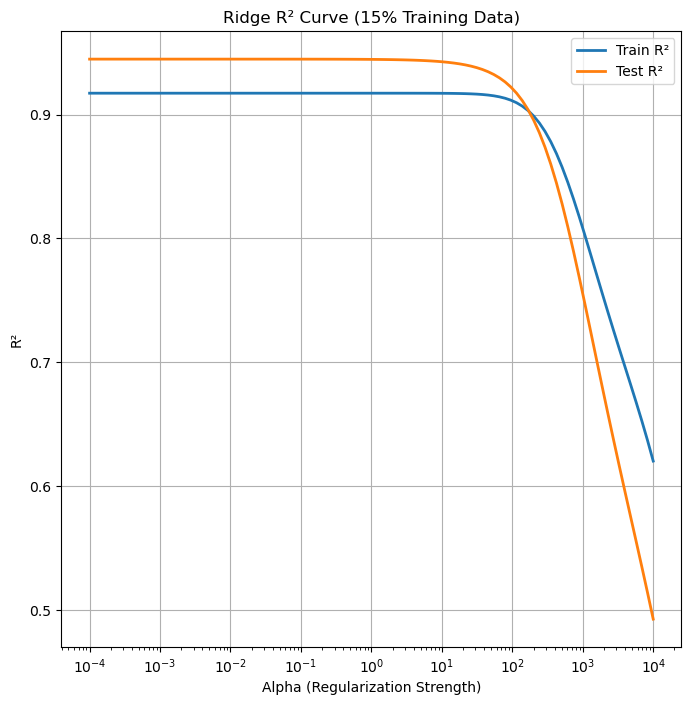

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9173143912073916

Results
----------------------------------------
Train MSE : 52.6487
Train R²  : 0.9173
Train RMSE : 7.2559
Test MSE  : 319.5329
Test R²   : 0.9448
Test RMSE  : 17.8755


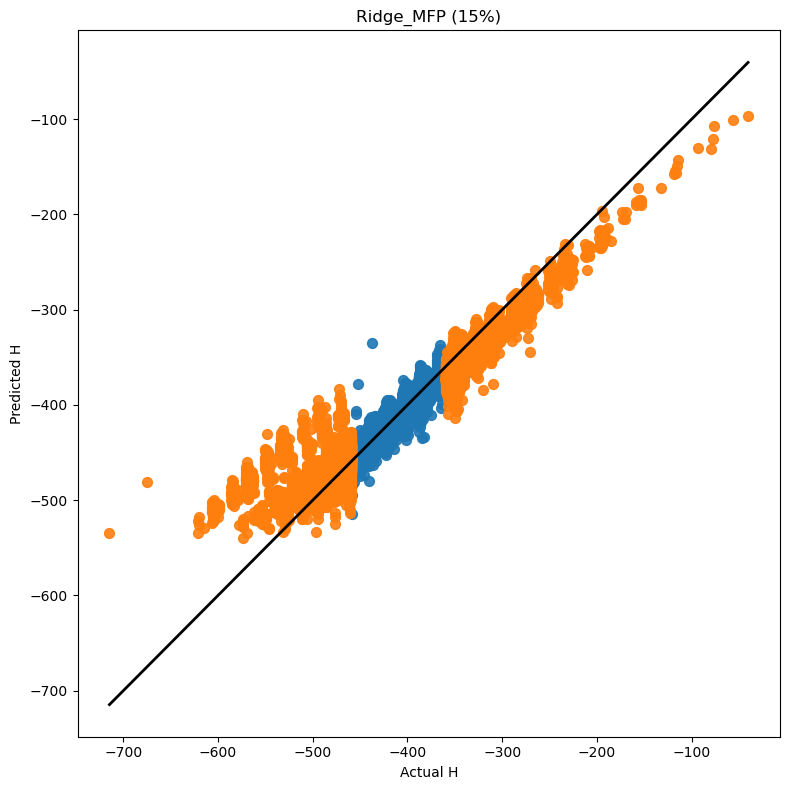


Training Fraction = 30%
Training Samples = 32704


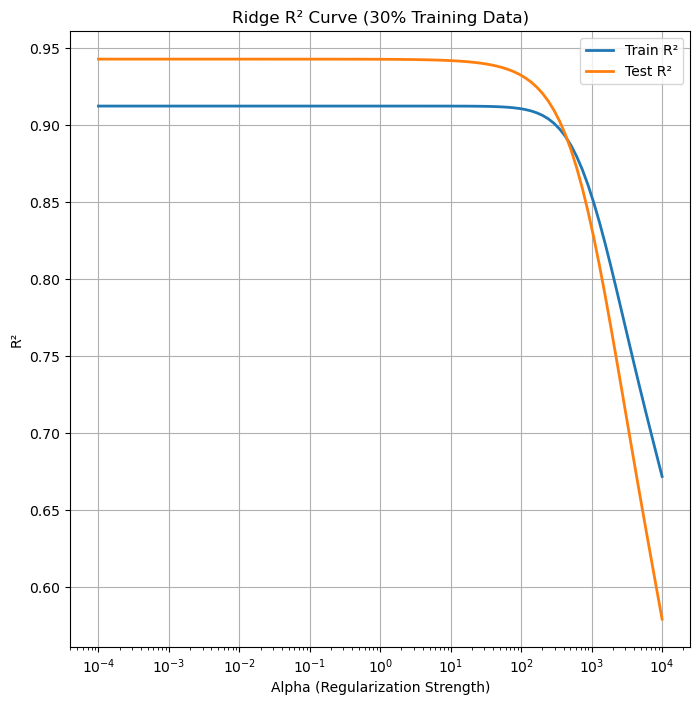

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9124618104783456

Results
----------------------------------------
Train MSE : 56.2115
Train R²  : 0.9125
Train RMSE : 7.4974
Test MSE  : 330.5500
Test R²   : 0.9429
Test RMSE  : 18.1810


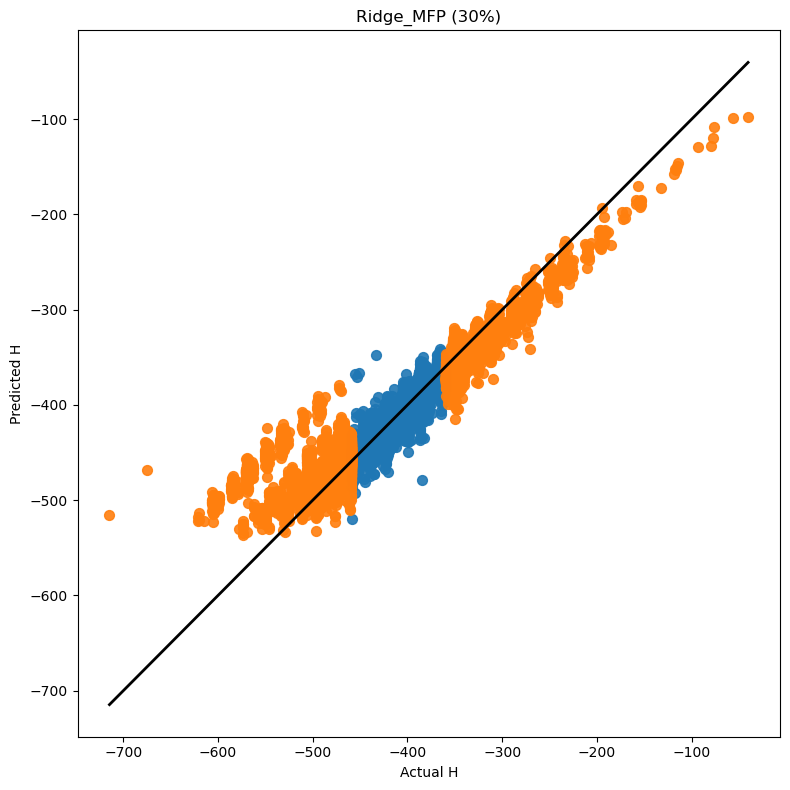


Training Fraction = 45%
Training Samples = 49057


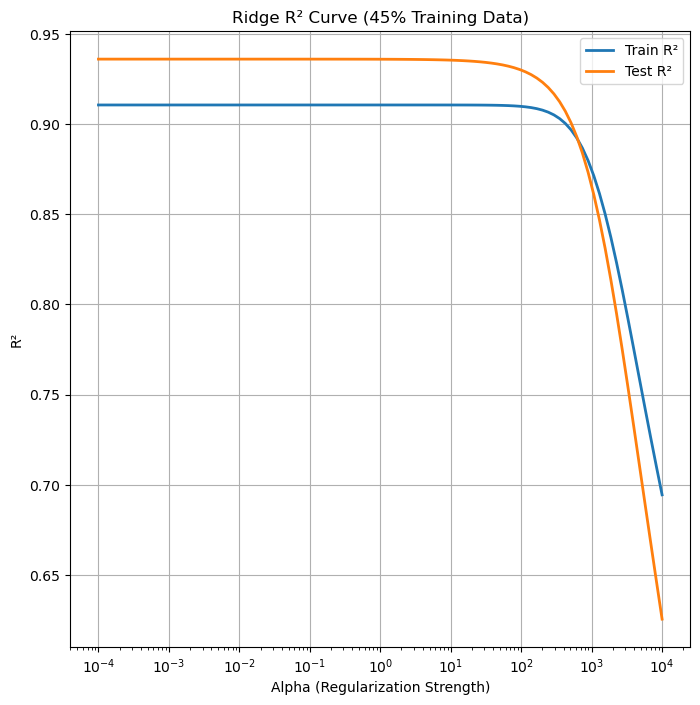

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9106305467892395

Results
----------------------------------------
Train MSE : 57.7502
Train R²  : 0.9106
Train RMSE : 7.5994
Test MSE  : 370.3624
Test R²   : 0.9361
Test RMSE  : 19.2448


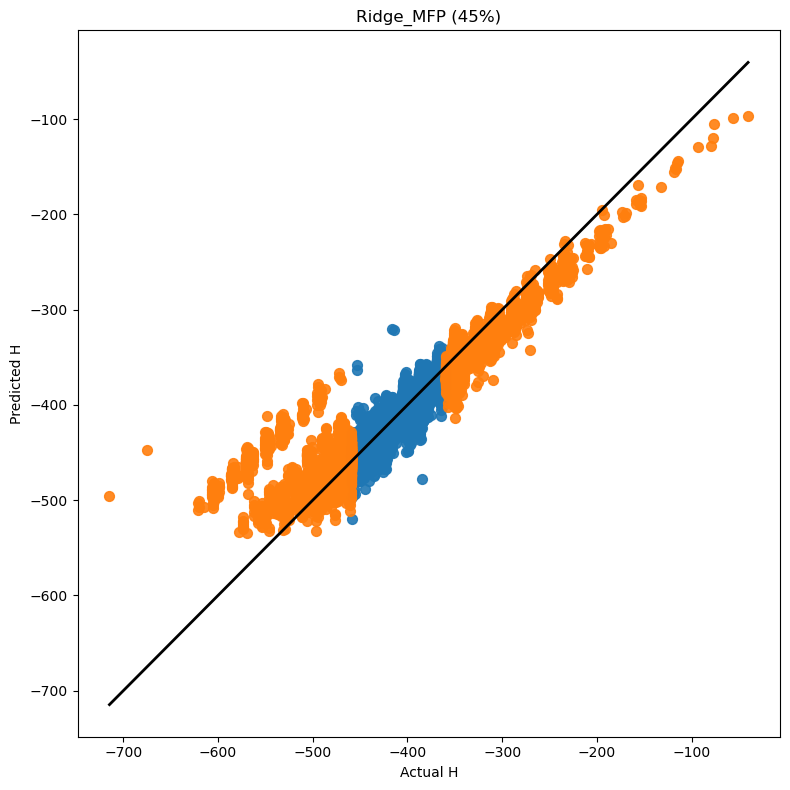


Training Fraction = 60%
Training Samples = 65409


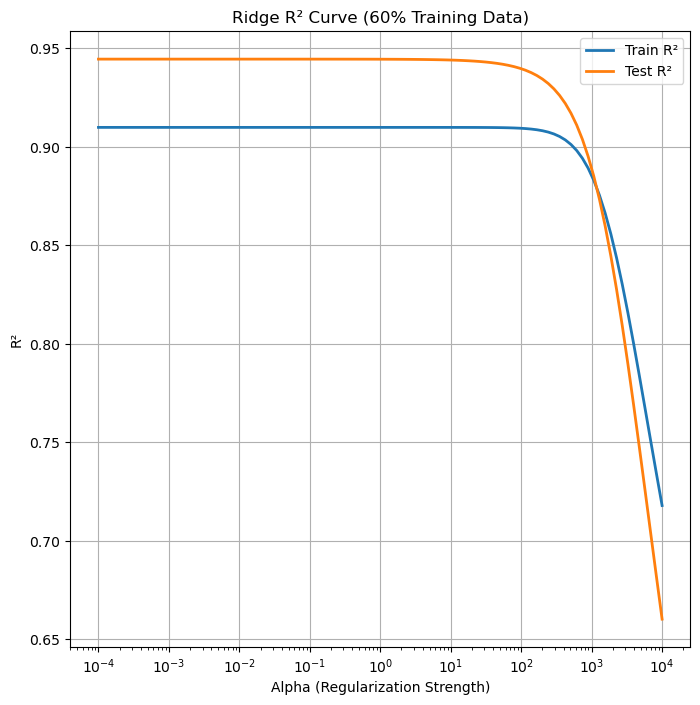

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9098893752552457

Results
----------------------------------------
Train MSE : 57.8948
Train R²  : 0.9099
Train RMSE : 7.6089
Test MSE  : 321.2615
Test R²   : 0.9445
Test RMSE  : 17.9238


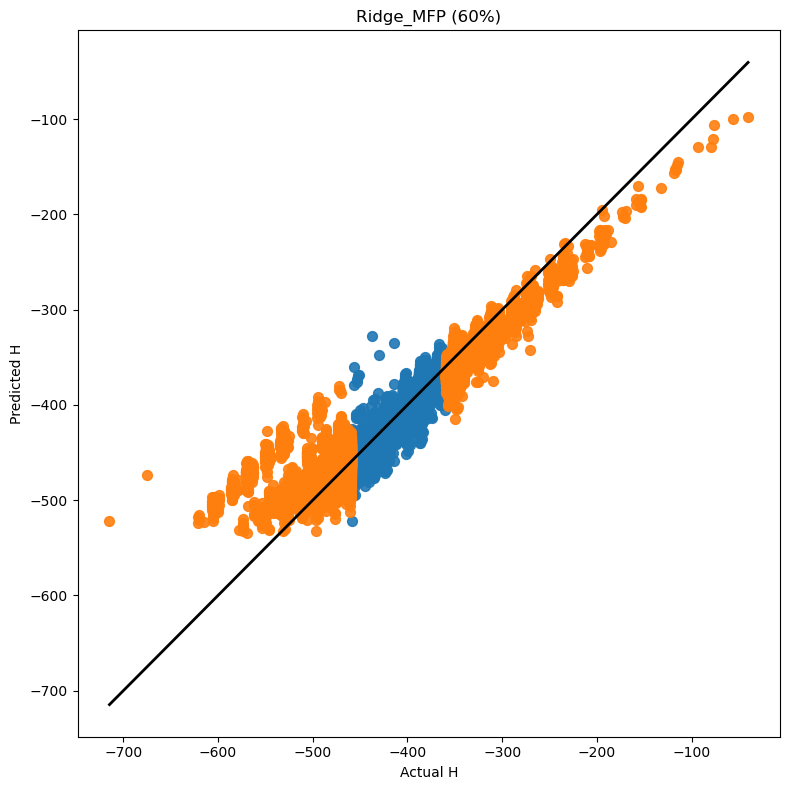


Training Fraction = 75%
Training Samples = 81762


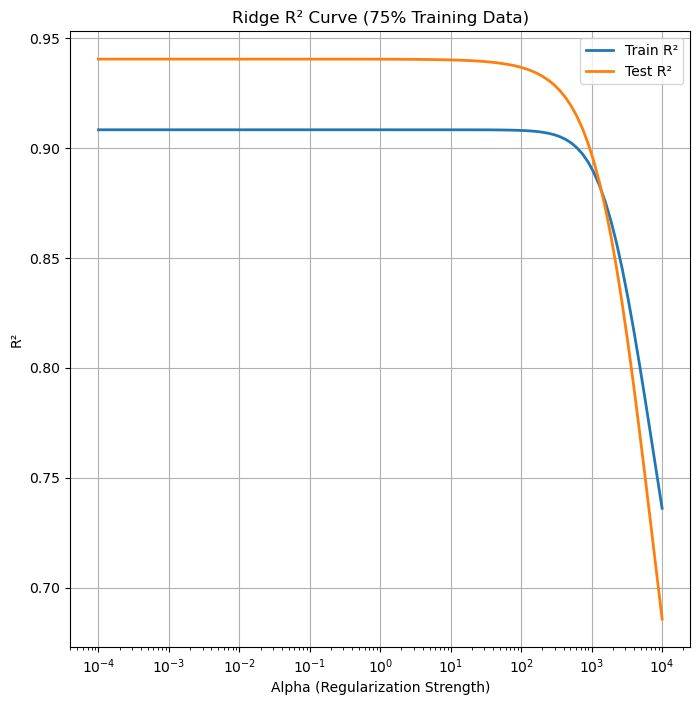

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9082276649724287

Results
----------------------------------------
Train MSE : 58.8833
Train R²  : 0.9082
Train RMSE : 7.6735
Test MSE  : 345.4147
Test R²   : 0.9404
Test RMSE  : 18.5853


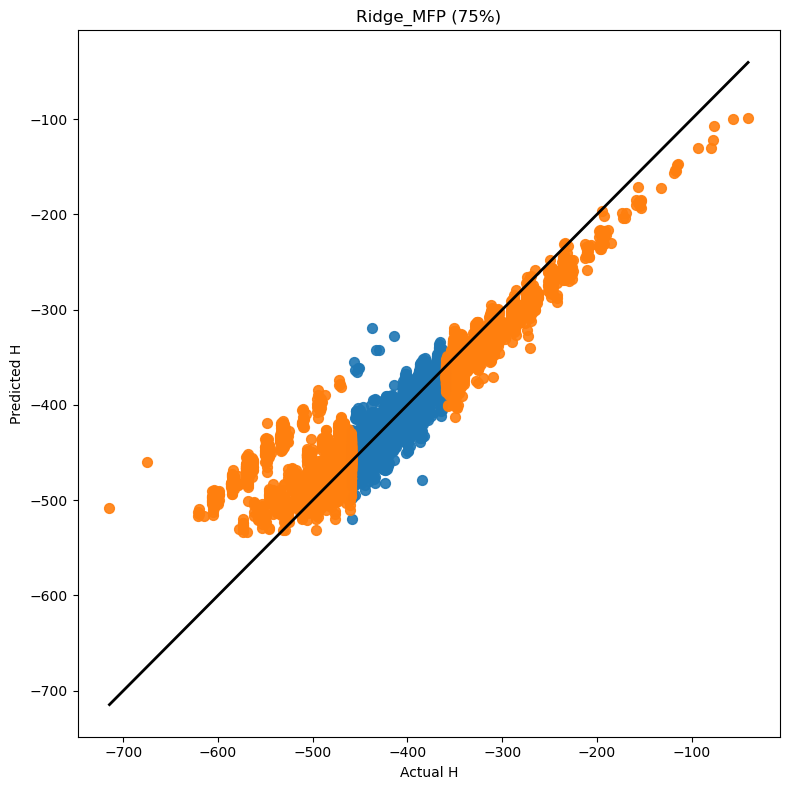


Training Fraction = 90%
Training Samples = 98114


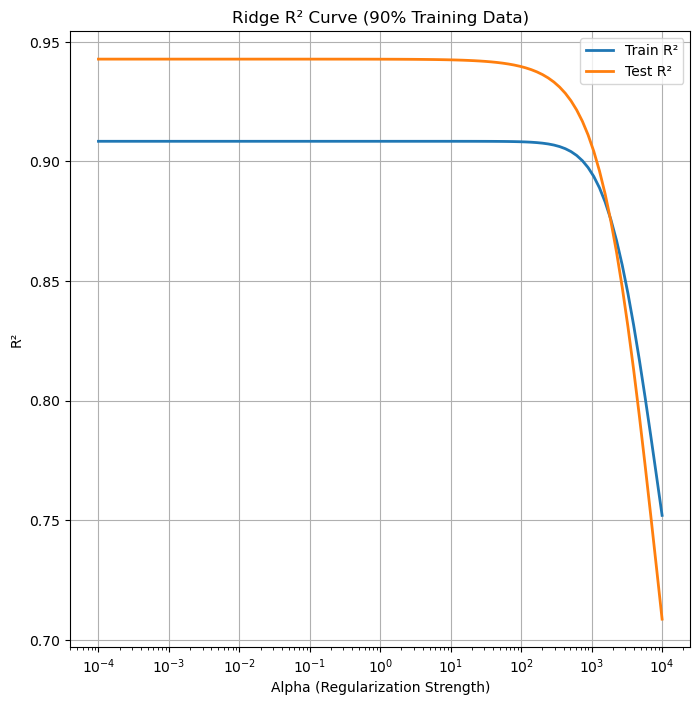

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9084193994058624

Results
----------------------------------------
Train MSE : 58.8336
Train R²  : 0.9084
Train RMSE : 7.6703
Test MSE  : 331.5000
Test R²   : 0.9428
Test RMSE  : 18.2071


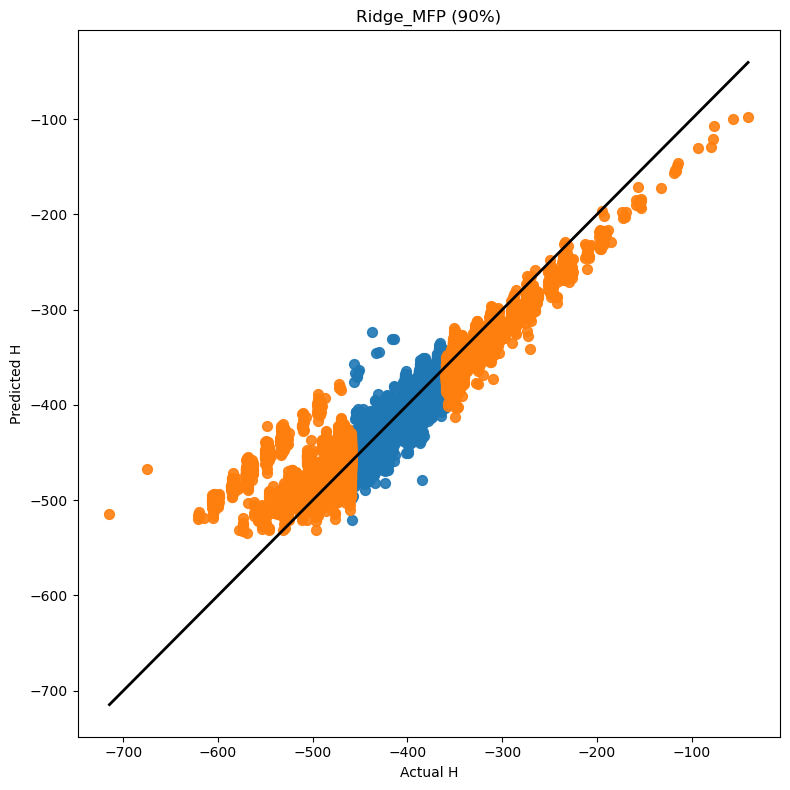

In [1]:
############################################################
# MORGAN FINGERPRINT-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge

from rdkit import Chem
from rdkit.Chem import AllChem

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"].values
print("Started")
# ===============================
# MORGAN FINGERPRINT OF SMILES
# ===============================
def smiles_to_count_fingerprint(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return np.zeros((2048,), dtype=int)

    fp = AllChem.GetHashedMorganFingerprint(
        mol,
        radius=2,
        nBits=2048
    )
    arr = np.zeros((2048,), dtype=int)
    for idx, count in fp.GetNonzeroElements().items():
        arr[idx] = count
    return arr

# Fingerprint Conversion
X = np.array([smiles_to_count_fingerprint(sm) for sm in smiles])
y = data["H"].values

print(X.shape)
print(X.dtype)
print("Success")

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]

# ===============================
# FIX TEST SET TO 24,869 SAMPLES
# ===============================

np.random.seed(42)

test_indices = np.random.choice(
    len(X_test_all),
    size=24869,
    replace=False
)

X_test = X_test_all[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Samples:", len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

# Alpha values (iterations equivalent)
alpha_values = np.logspace(-4, 4, 100)

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )

    X_train_sub = X_train_full[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    # ===============================
    # SCALING
    # ===============================

    x_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_sub)
    X_test_scaled = x_scaler.transform(X_test)

    # ===============================
    # RIDGE REGRESSION
    # ===============================

    train_r2_list = []
    test_r2_list = []

    for alpha in alpha_values:

        ridge = Ridge(alpha=alpha)

        ridge.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = ridge.predict(X_train_scaled)
        y_pred_test_iter = ridge.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    # ===============================
    # PLOT R² vs ALPHA
    # ===============================

    plt.figure(figsize=(8,8))

    plt.plot(
        alpha_values,
        train_r2_list,
        label='Train R²',
        linewidth=2
    )

    plt.plot(
        alpha_values,
        test_r2_list,
        label='Test R²',
        linewidth=2
    )

    plt.xscale('log')

    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('R²')
    plt.title(f'Ridge R² Curve ({int(frac*100)}% Training Data)')
    plt.legend()
    plt.grid(True)

    plt.show()

    # ===============================
    # STABLE ALPHA VALUE
    # ===============================
    train_r2_array = np.array(train_r2_list)
    impovement = np.abs(np.diff(train_r2_array))
    thershold = 1e-4
    stable_indices = np.where(impovement<thershold)[0]
    if len(stable_indices) > 0:
        stable_start = stable_indices[0] + 1
        best_alpha = alpha_values[stable_start]
    else:
        best_alpha = alpha_values[np.argmax(train_r2_array)]
        
    best_r2 = train_r2_array[stable_start] if len(stable_indices) > 0 else np.max(train_r2_array)
    print("selected Alpha =", best_alpha)
    print("train R² at stable region =", best_r2)

    # ===============================
    # FINAL MODEL USING BEST ALPHA
    # ===============================

    ridge = Ridge(alpha=best_alpha)

    ridge.fit(X_train_scaled, y_train_sub)

    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE  : {rmse_test:.4f}")
    
    # ===============================
    # TRAIN PARITY PLOT
    # ===============================

    plt.figure(figsize=(8,8))

    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.9
    )

    # ===============================
    # TEST PARITY PLOT
    # ===============================
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'k-',
        linewidth=2
    )

    plt.xlabel('Actual H')
    plt.ylabel('Predicted H')
    plt.title(f'Ridge_MFP ({int(frac*100)}%)')
    plt.savefig(f"MFP_RR_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')
    plt.tight_layout()
    plt.show()



Started
Shape: (133885, 5)
Index(['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumHeteroatoms'], dtype='object')
Total Descriptor used:           MolWt  HeavyAtomMolWt  ExactMolWt  NumHeteroatoms
0        16.043          12.011   16.031300               0
1        17.031          14.007   17.026549               1
2        18.015          15.999   18.010565               1
3        26.038          24.022   26.015650               0
4        27.026          26.018   27.010899               1
...         ...             ...         ...             ...
133880  121.139         114.083  121.052764               2
133881  121.139         114.083  121.052764               2
133882  120.155         112.091  120.068748               2
133883  119.167         110.095  119.073499               1
133884  121.139         114.083  121.052764               2

[133885 rows x 4 columns]
Train H range: -459.185274 -360.000294
Test H range : -714.559209 -40.475117
Train samples: 109016
Test samples : 24869


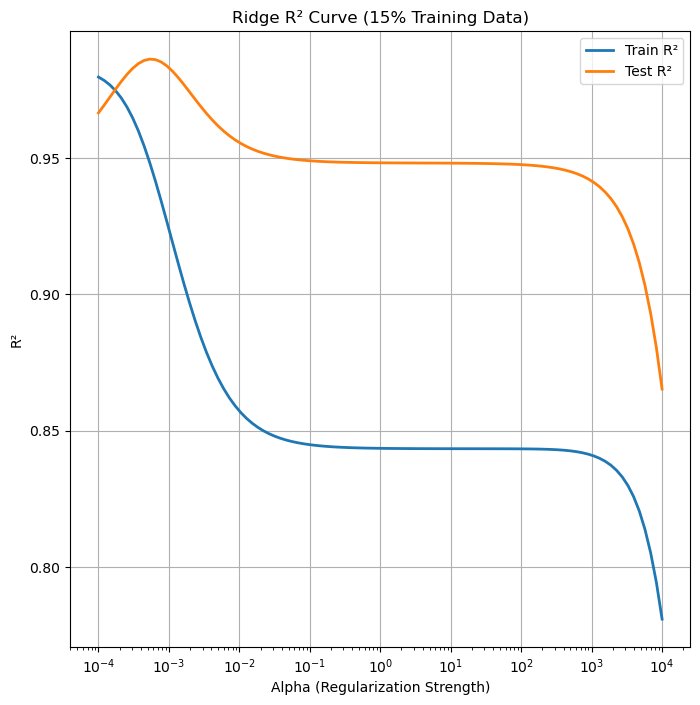

selected Alpha = 0.3593813663804629
train R² at stable region = 0.843804566457224

Results
----------------------------------------
Train MSE : 99.4549
Train R²  : 0.8438
Train RMSE : 9.9727
Test MSE  : 299.3354
Test R²   : 0.9483
Test RMSE  : 17.3013
Train std: 25.233577065083434
Test std : 76.10459743243425


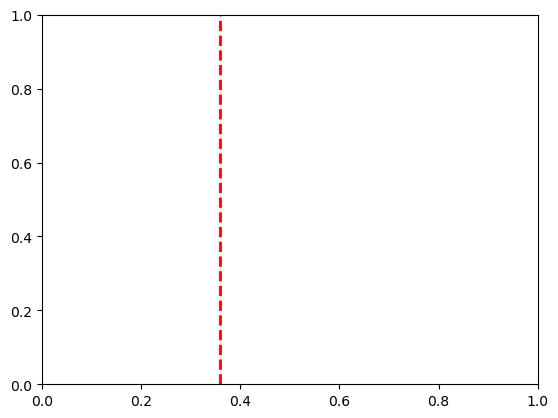

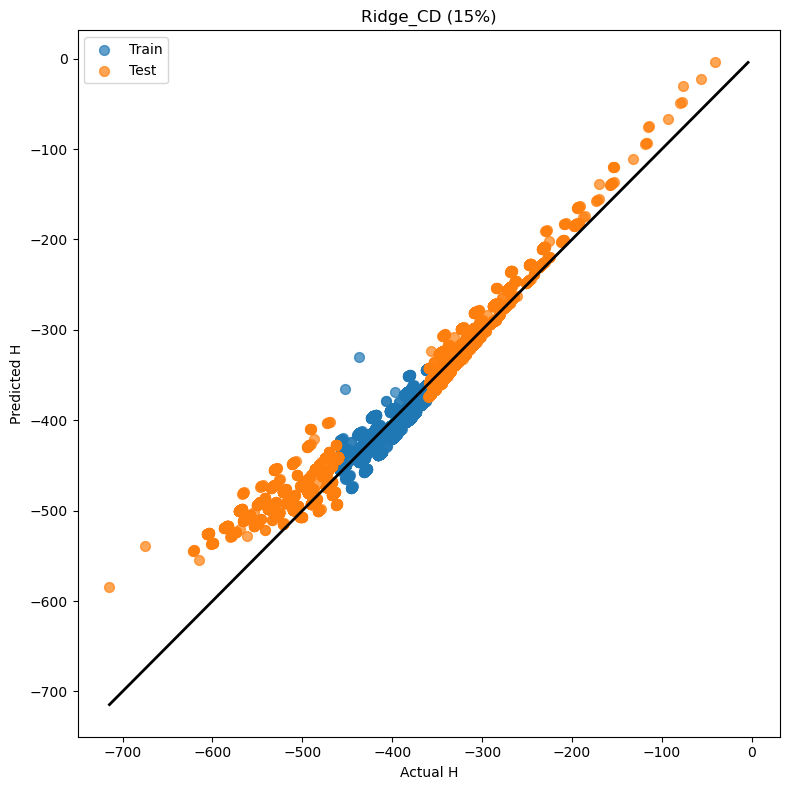


Training Fraction = 30%
Training Samples = 32704


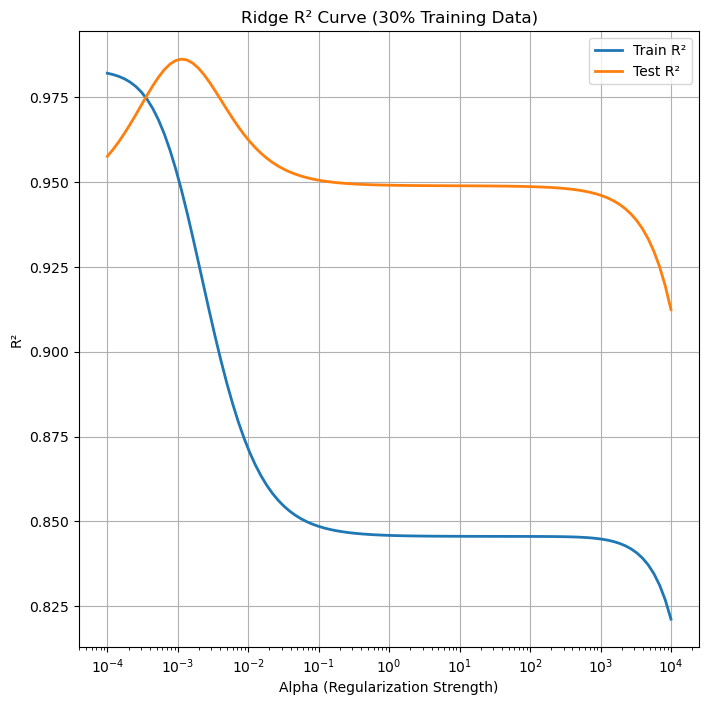

selected Alpha = 0.6280291441834259
train R² at stable region = 0.846064054743522

Results
----------------------------------------
Train MSE : 98.8480
Train R²  : 0.8461
Train RMSE : 9.9422
Test MSE  : 294.5644
Test R²   : 0.9491
Test RMSE  : 17.1629
Train std: 25.340426816468753
Test std : 76.10459743243425


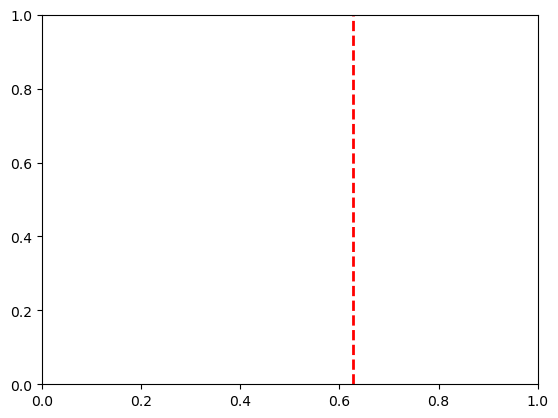

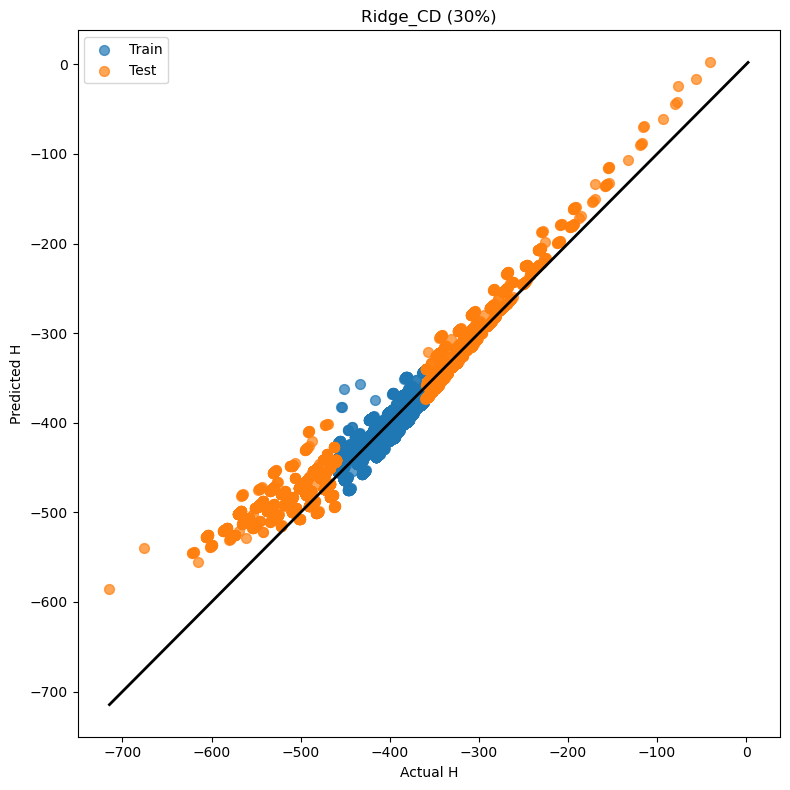


Training Fraction = 45%
Training Samples = 49057


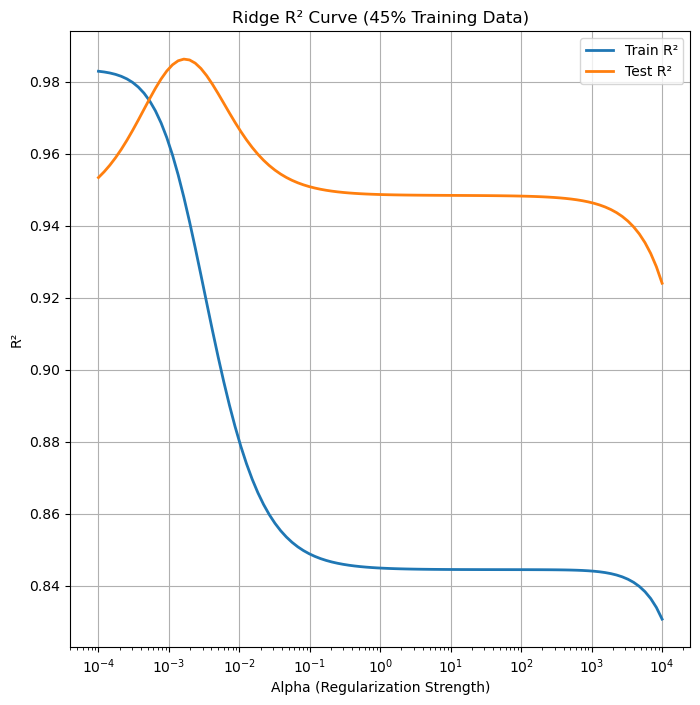

selected Alpha = 0.9111627561154896
train R² at stable region = 0.8449087558398503

Results
----------------------------------------
Train MSE : 100.2193
Train R²  : 0.8449
Train RMSE : 10.0110
Test MSE  : 297.1848
Test R²   : 0.9487
Test RMSE  : 17.2390
Train std: 25.420385167529368
Test std : 76.10459743243425


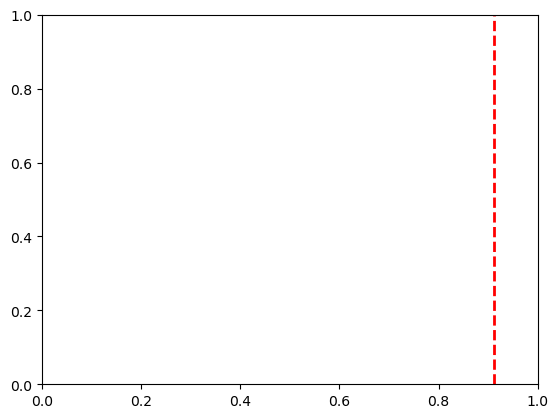

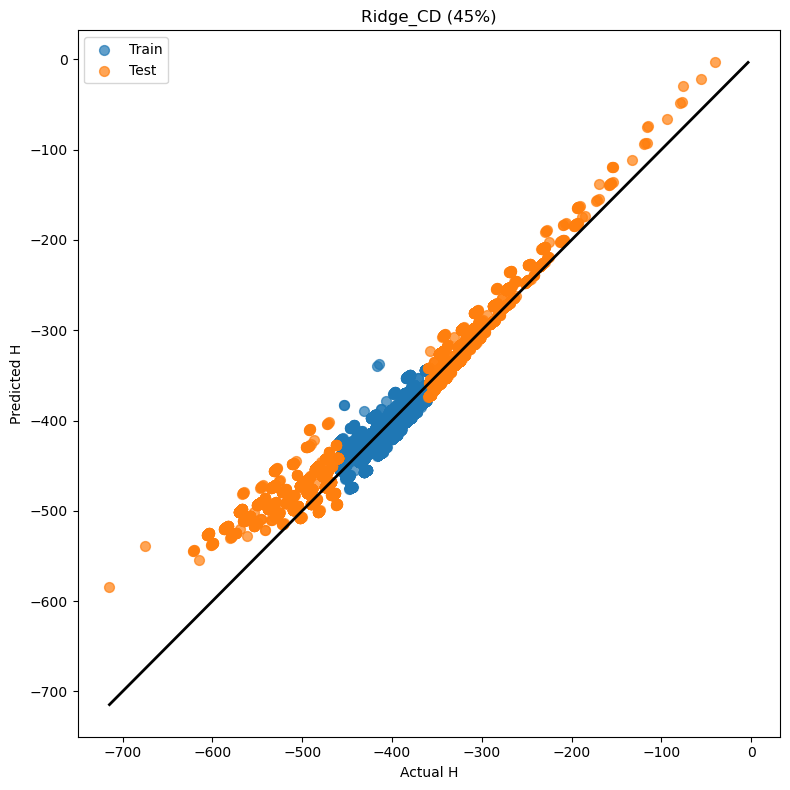


Training Fraction = 60%
Training Samples = 65409


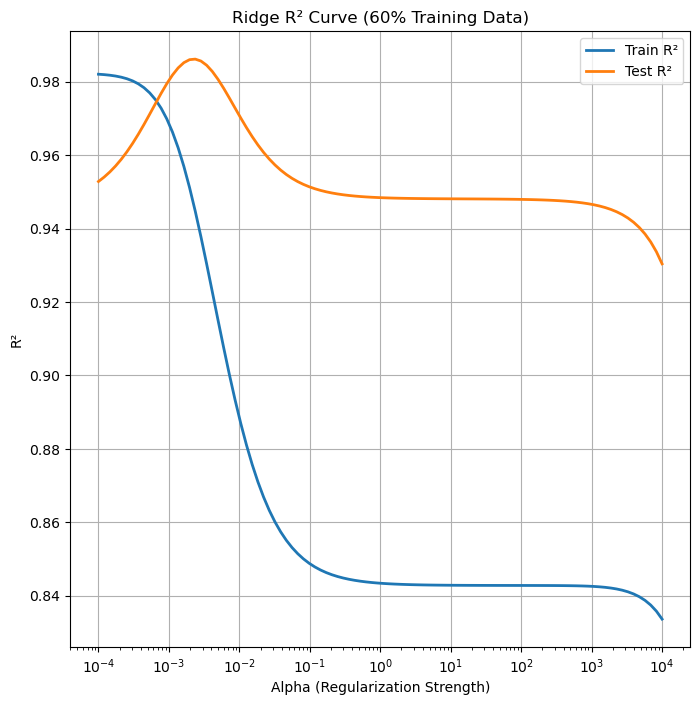

selected Alpha = 1.3219411484660315
train R² at stable region = 0.8432593013174894

Results
----------------------------------------
Train MSE : 100.7036
Train R²  : 0.8433
Train RMSE : 10.0351
Test MSE  : 299.2026
Test R²   : 0.9483
Test RMSE  : 17.2975
Train std: 25.34729570146164
Test std : 76.10459743243425


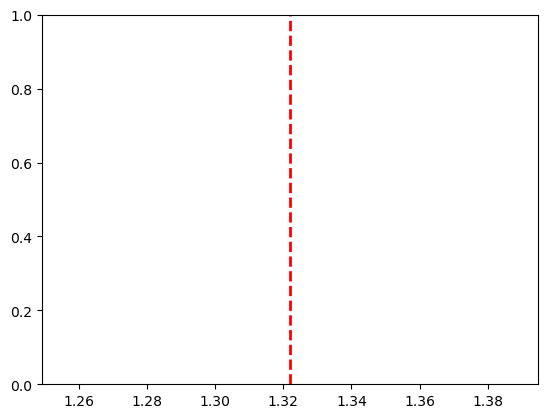

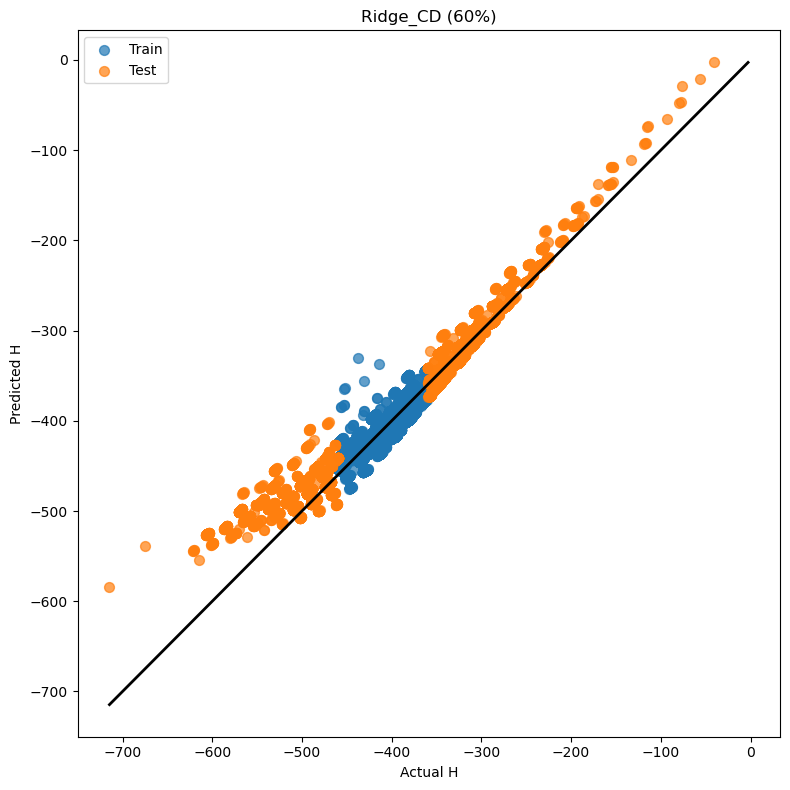


Training Fraction = 75%
Training Samples = 81762


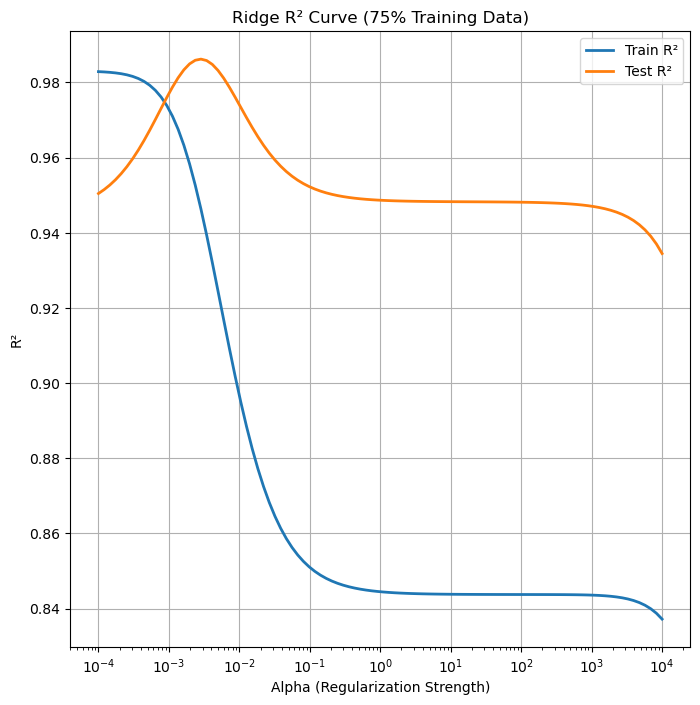

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9828088069368579

Results
----------------------------------------
Train MSE : 11.0303
Train R²  : 0.9828
Train RMSE : 3.3212
Test MSE  : 280.9185
Test R²   : 0.9515
Test RMSE  : 16.7606
Train std: 25.330286931683766
Test std : 76.10459743243425


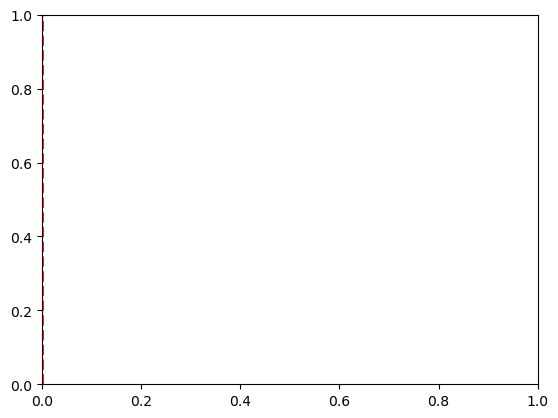

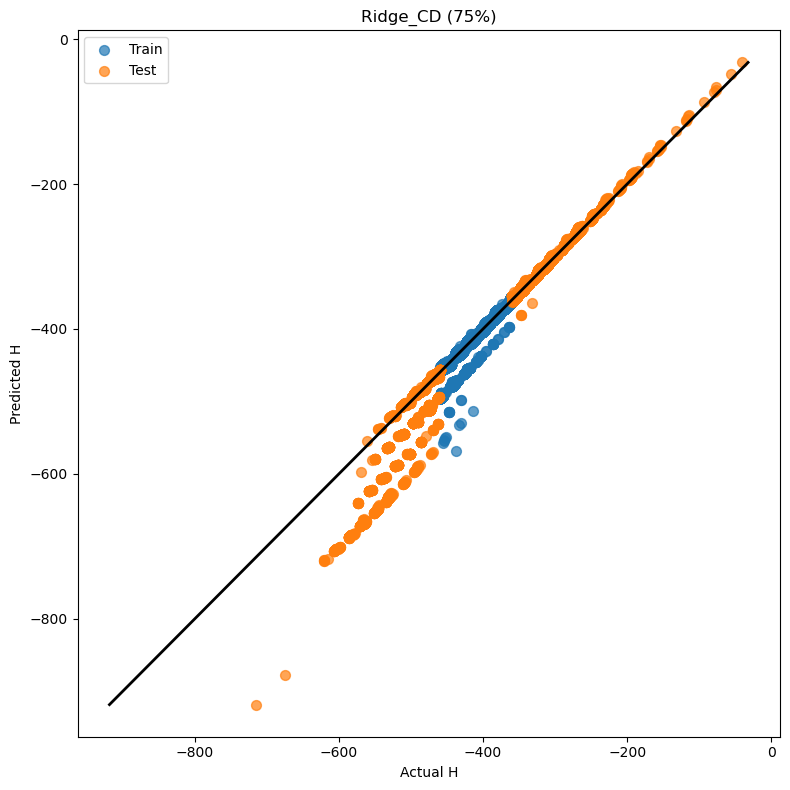


Training Fraction = 90%
Training Samples = 98114


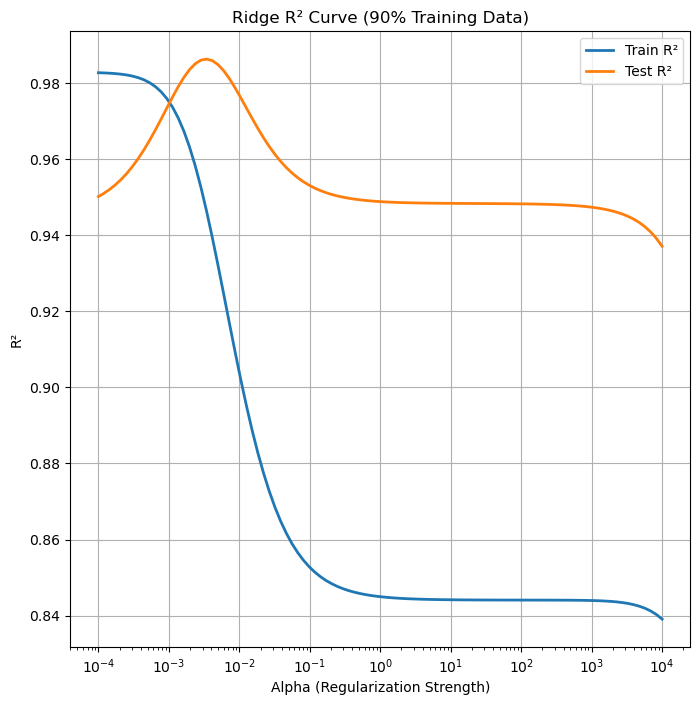

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9826013232185014

Results
----------------------------------------
Train MSE : 11.1773
Train R²  : 0.9826
Train RMSE : 3.3433
Test MSE  : 283.7861
Test R²   : 0.9510
Test RMSE  : 16.8460
Train std: 25.346093586232445
Test std : 76.10459743243425


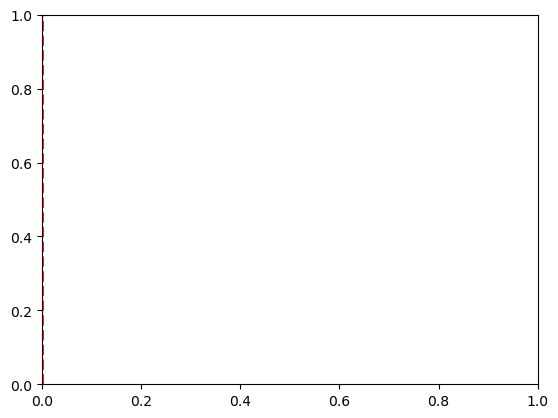

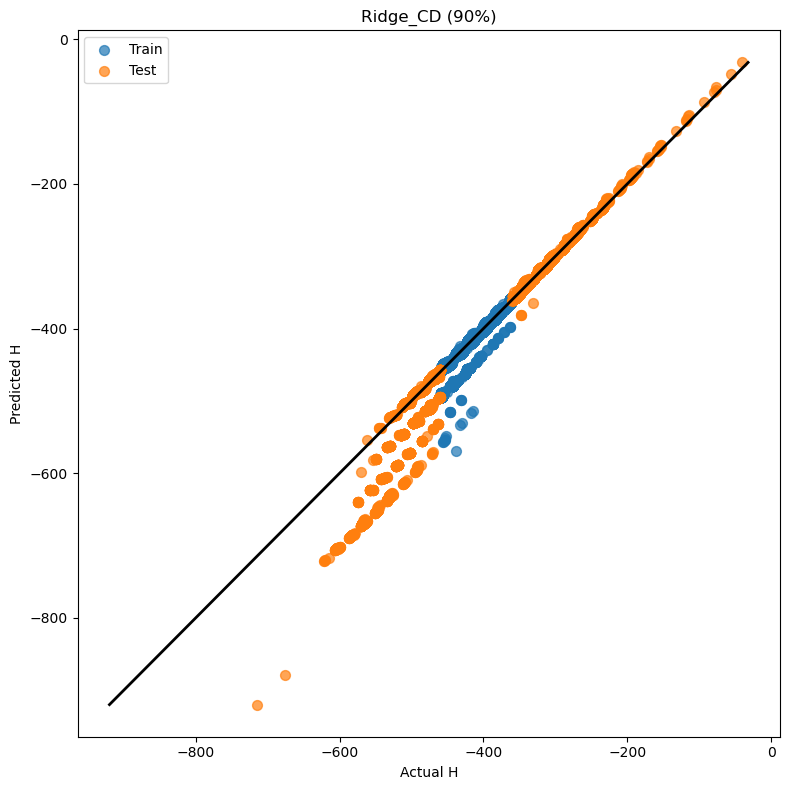

In [3]:
############################################################
# CHEMICAL DESCRIPTOR-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"].values
y = data["H"].values
print("Started")
# ===============================
# CHEMICAL DESCRIPTOR WITH FEATURE SELECTION
# ===============================
X_df = pd.read_csv("selected_descriptors.csv")
X = X_df.drop(columns=["SMILES"])
print("Shape:", X_df.shape)
print(X.columns)
print("Total Descriptor used:",X)

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]
print("Train H range:", y_train_full.min(), y_train_full.max())
print("Test H range :", y_test_all.min(), y_test_all.max())

print("Train samples:", len(y_train_full))
print("Test samples :", len(y_test_all))

# ===============================
# FIX TEST SET TO 24,869 SAMPLES
# ===============================

np.random.seed(42)

test_indices = np.random.choice(
    len(X_test_all),
    size=24869,
    replace=False
)

X_test = X_test_all.iloc[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Samples:", len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

# Alpha values (iterations equivalent)
alpha_values = np.logspace(-4, 4, 100)

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )

    X_train_sub = X_train_full.iloc[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    # ===============================
    # SCALING
    # ===============================

    x_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_sub)
    X_test_scaled = x_scaler.transform(X_test)
    
    # ===============================
    # RIDGE REGRESSION
    # ===============================

    train_r2_list = []
    test_r2_list = []

    for alpha in alpha_values:

        ridge = Ridge(alpha=alpha)

        ridge.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = ridge.predict(X_train_scaled)
        y_pred_test_iter = ridge.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    # ===============================
    # PLOT R² vs ALPHA
    # ===============================

    plt.figure(figsize=(8,8))

    plt.plot(
        alpha_values,
        train_r2_list,
        label='Train R²',
        linewidth=2
    )

    plt.plot(
        alpha_values,
        test_r2_list,
        label='Test R²',
        linewidth=2
    )

    plt.xscale('log')

    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('R²')
    plt.title(f'Ridge R² Curve ({int(frac*100)}% Training Data)')
    plt.legend()
    plt.grid(True)

    plt.show()

    # ===============================
    # STABLE ALPHA VALUE
    # ===============================
    train_r2_array = np.array(train_r2_list)
    impovement = np.abs(np.diff(train_r2_array))
    thershold = 1e-4
    stable_indices = np.where(impovement<thershold)[0]
    if len(stable_indices) > 0:
        stable_start = stable_indices[0] + 1
        best_alpha = alpha_values[stable_start]
    else:
        best_alpha = alpha_values[np.argmax(train_r2_array)]
        
    best_r2 = train_r2_array[stable_start] if len(stable_indices) > 0 else np.max(train_r2_array)
    print("selected Alpha =", best_alpha)
    print("train R² at stable region =", best_r2)

    plt.axvline(best_alpha,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Selected α={best_alpha:.4f}')

    # ===============================
    # FINAL MODEL USING BEST ALPHA
    # ===============================

    ridge = Ridge(alpha=best_alpha)

    ridge.fit(X_train_scaled, y_train_sub)

    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE  : {rmse_test:.4f}")
    print("Train std:", np.std(y_train_sub))
    print("Test std :", np.std(y_test))


    # ===============================
    # PARITY PLOT
    # ===============================
    plt.figure(figsize=(8,8))

    # Train points
    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.7,
        label='Train'
    )

    # Test points
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.7,
        label='Test'
    )

    # Determine limits using both train and test
    min_val = min(
        y_train_sub.min(),
        y_pred_train.min(),
        y_test.min(),
        y_pred_test.min()
    )

    max_val = max(
        y_train_sub.max(),
        y_pred_train.max(),
        y_test.max(),
        y_pred_test.max()
    )

    # x = y reference line
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'k-',
        linewidth=2,
    )

    plt.xlabel('Actual H')
    plt.ylabel('Predicted H')
    plt.title(f'Ridge_CD ({int(frac*100)}%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"CD_RR_Parity_{int(frac*100)}.png",
        dpi=600,
        bbox_inches='tight'
    )
    plt.show()

Total Descriptors: 208
Started
success
Train H range: -459.185274 -360.000294
Test H range : -714.559209 -40.475117
Train samples: 109016
Test samples : 24869
Fixed Test Samples: 24869

Training Fraction = 15%
Training Samples = 16352


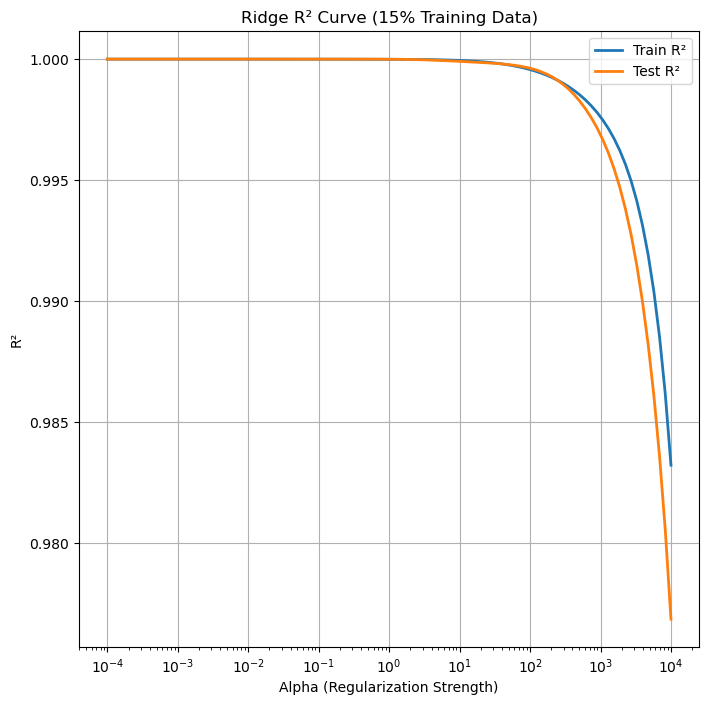

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999996987979516

Results
----------------------------------------
Train MSE : 0.0002
Train R²  : 1.0000
Train RMSE : 0.0138
Test MSE  : 0.0005
Test R²   : 1.0000
Test RMSE  : 0.0221
Train std: 25.233577065083434
Test std : 76.10459743243425


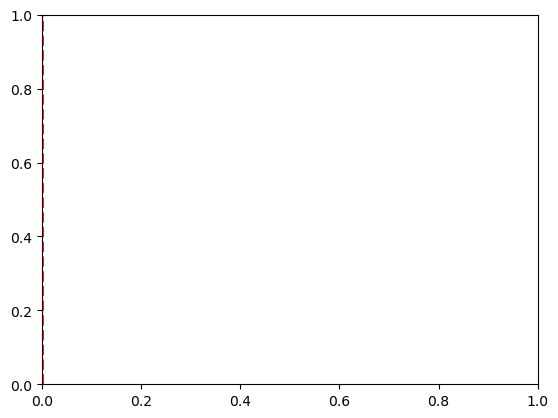

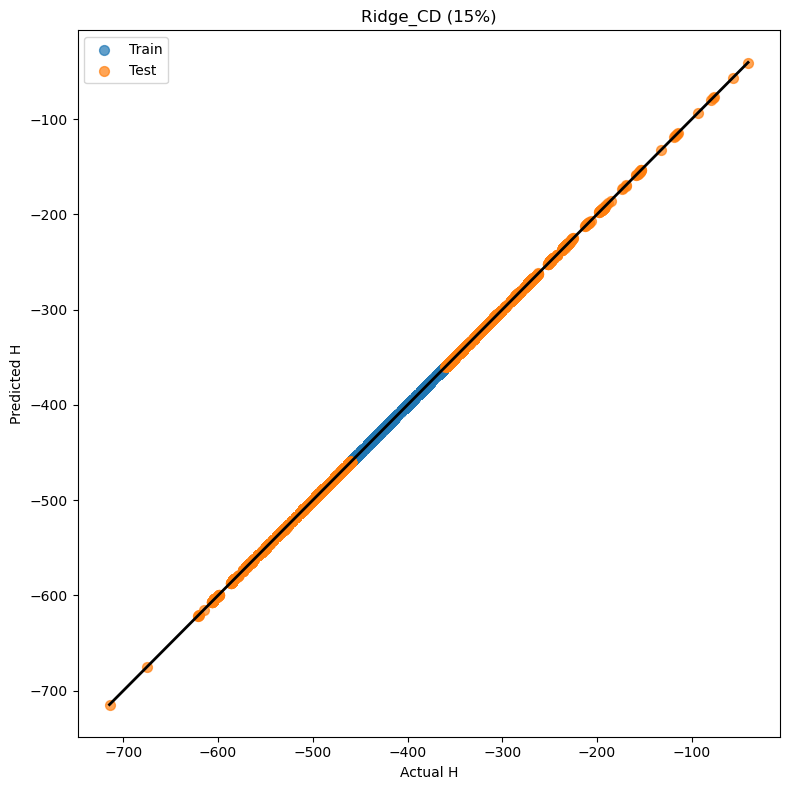


Training Fraction = 30%
Training Samples = 32704


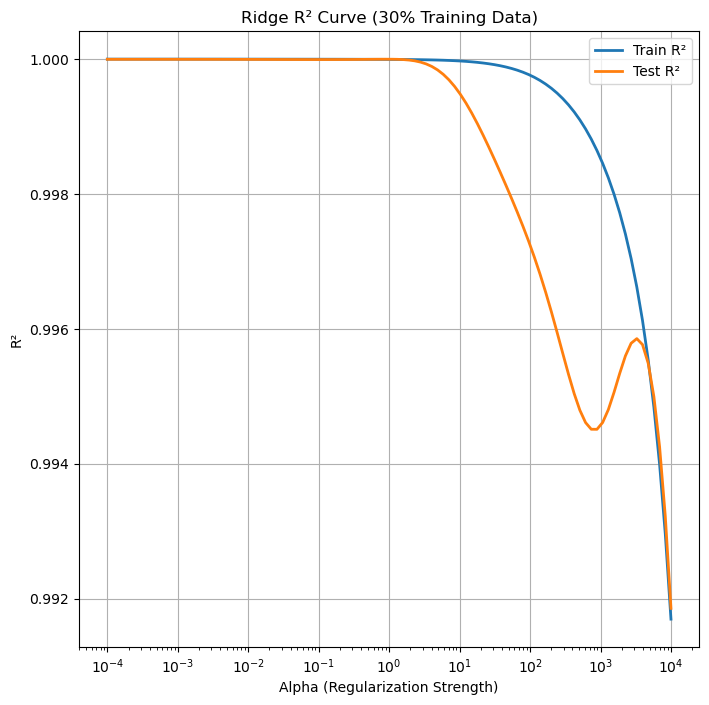

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999997131261311

Results
----------------------------------------
Train MSE : 0.0002
Train R²  : 1.0000
Train RMSE : 0.0136
Test MSE  : 0.0171
Test R²   : 1.0000
Test RMSE  : 0.1309
Train std: 25.340426816468753
Test std : 76.10459743243425


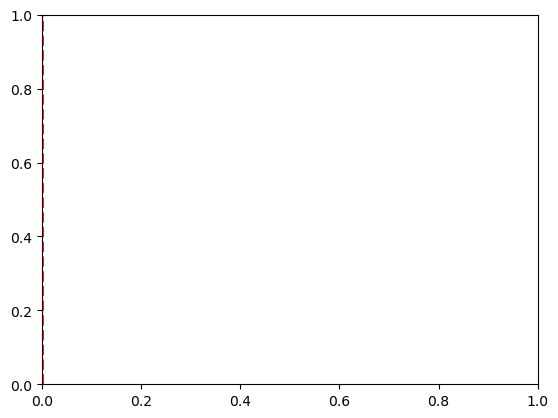

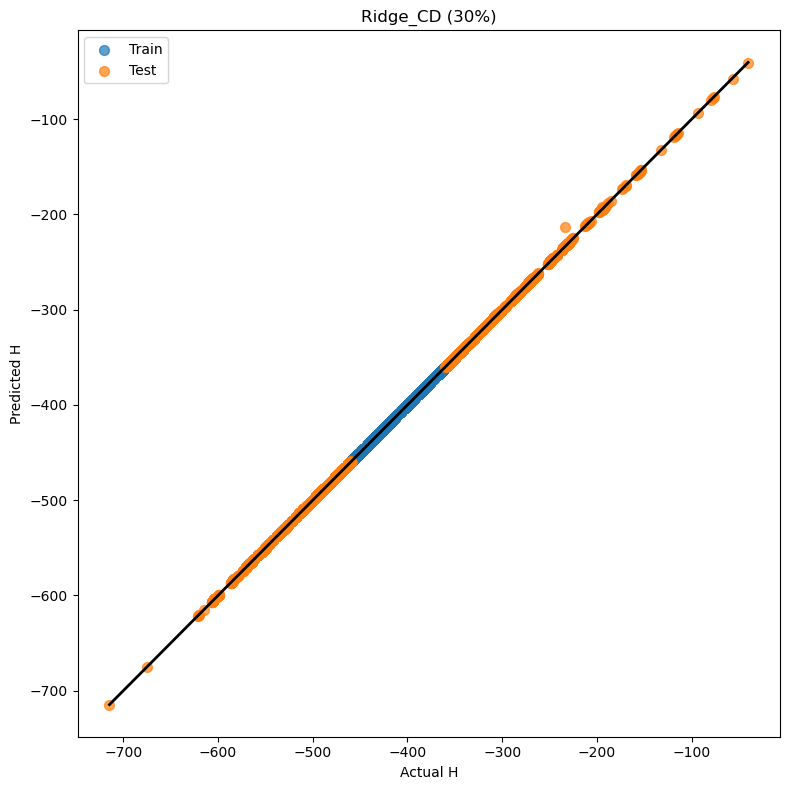


Training Fraction = 45%
Training Samples = 49057


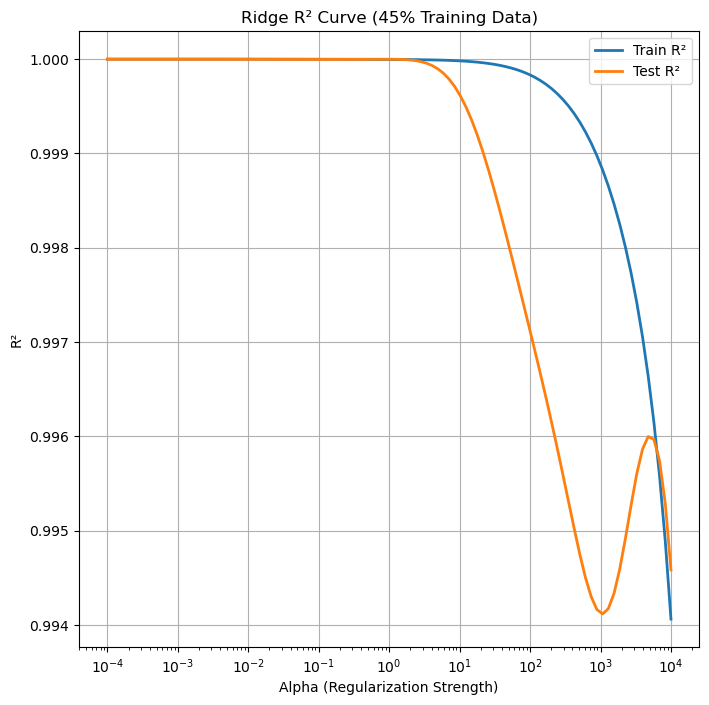

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999997140201978

Results
----------------------------------------
Train MSE : 0.0002
Train R²  : 1.0000
Train RMSE : 0.0136
Test MSE  : 0.0124
Test R²   : 1.0000
Test RMSE  : 0.1113
Train std: 25.420385167529368
Test std : 76.10459743243425


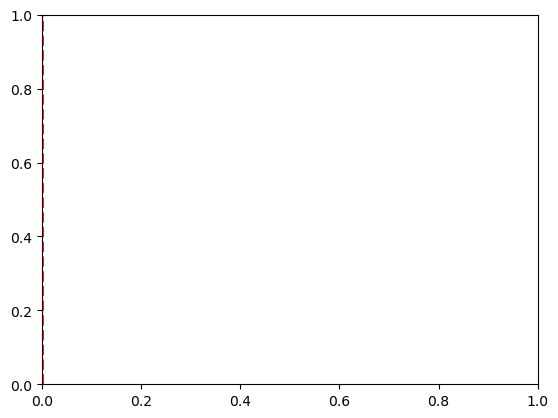

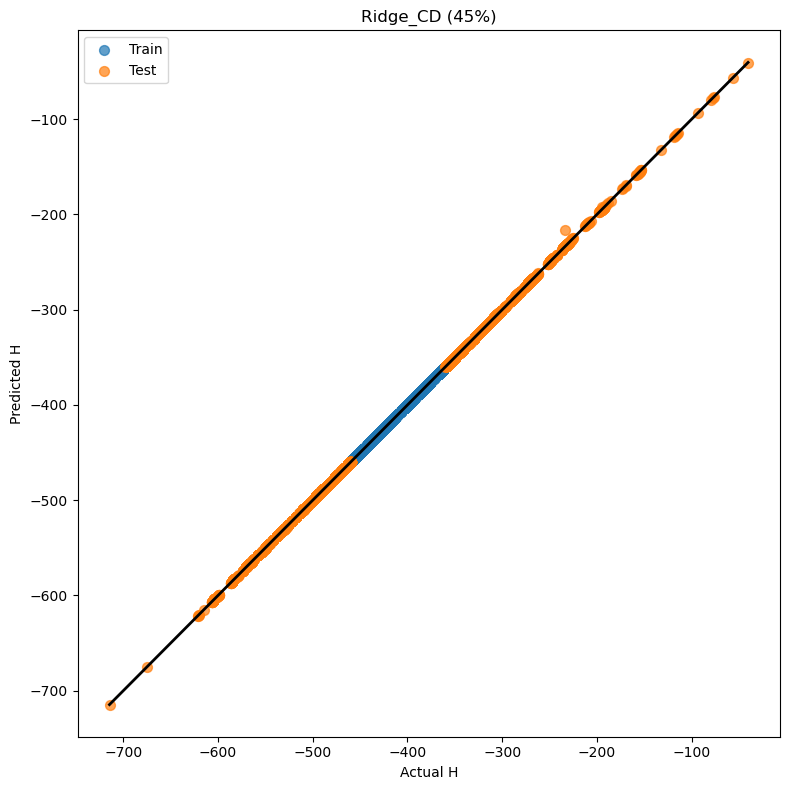


Training Fraction = 60%
Training Samples = 65409


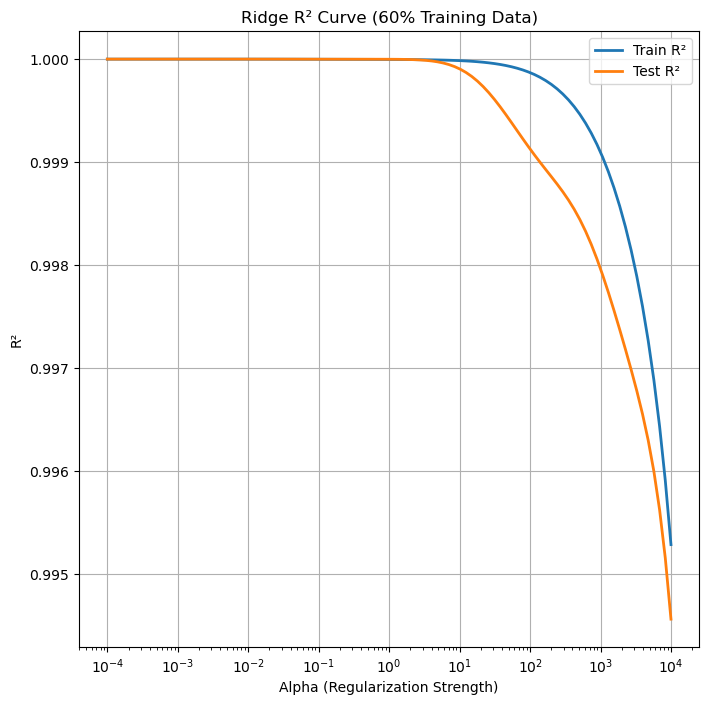

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.9999997095609928

Results
----------------------------------------
Train MSE : 0.0002
Train R²  : 1.0000
Train RMSE : 0.0137
Test MSE  : 0.0003
Test R²   : 1.0000
Test RMSE  : 0.0165
Train std: 25.34729570146164
Test std : 76.10459743243425


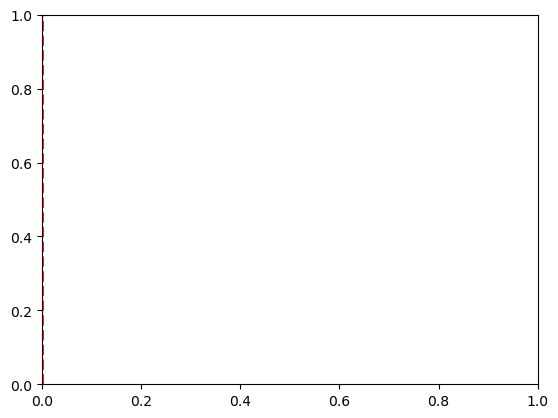

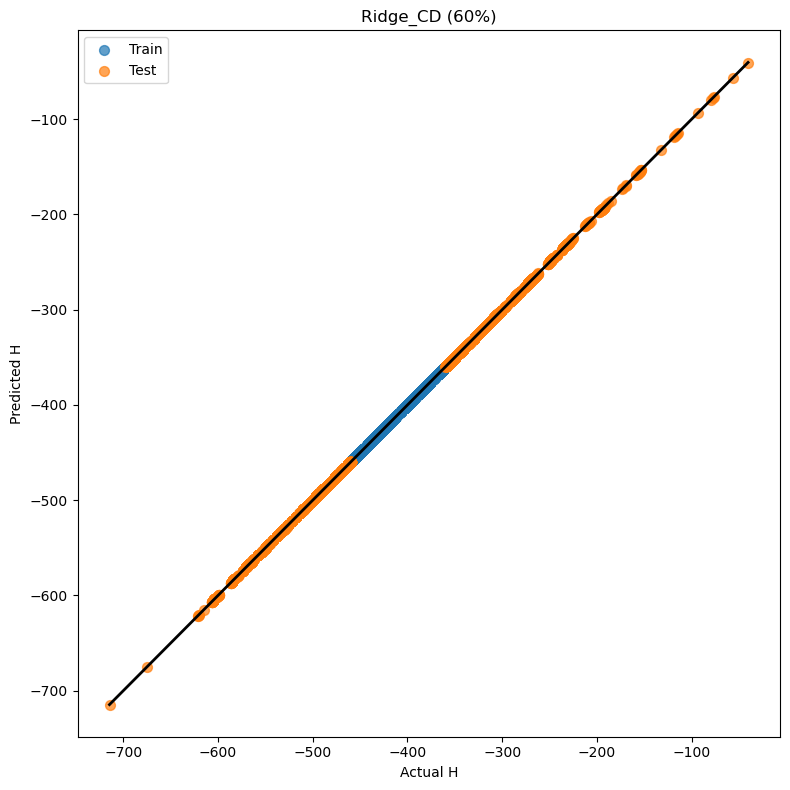


Training Fraction = 75%
Training Samples = 81762


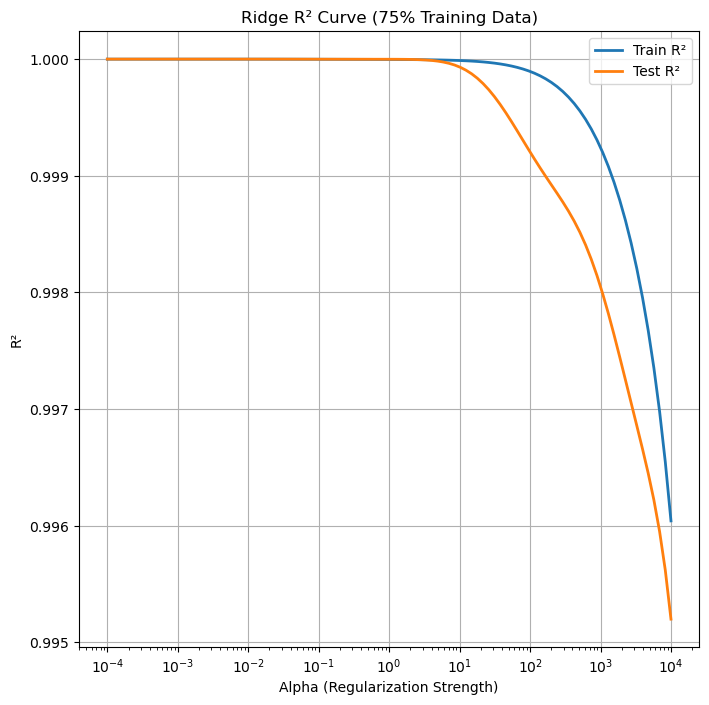

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.999999710427056

Results
----------------------------------------
Train MSE : 0.0002
Train R²  : 1.0000
Train RMSE : 0.0136
Test MSE  : 0.0003
Test R²   : 1.0000
Test RMSE  : 0.0180
Train std: 25.330286931683766
Test std : 76.10459743243425


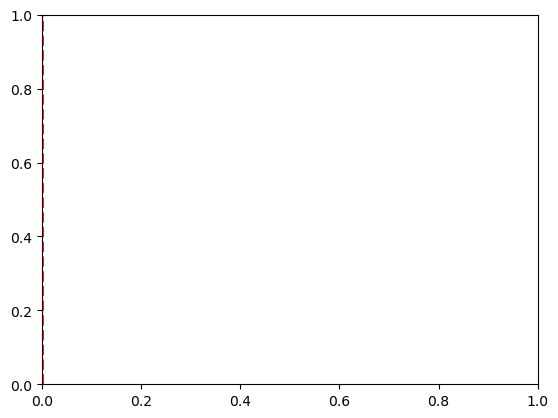

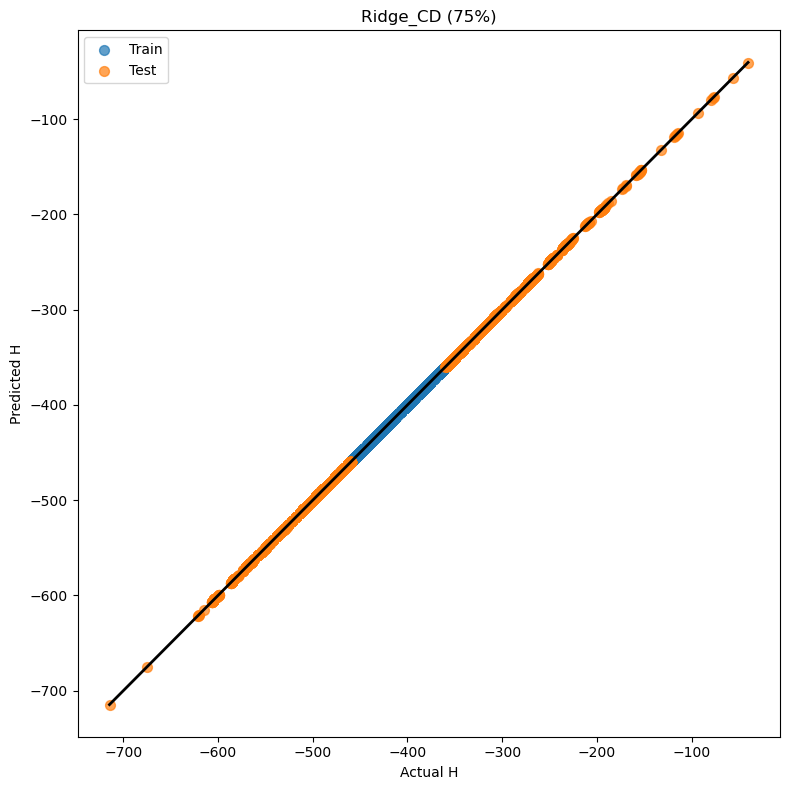


Training Fraction = 90%
Training Samples = 98114


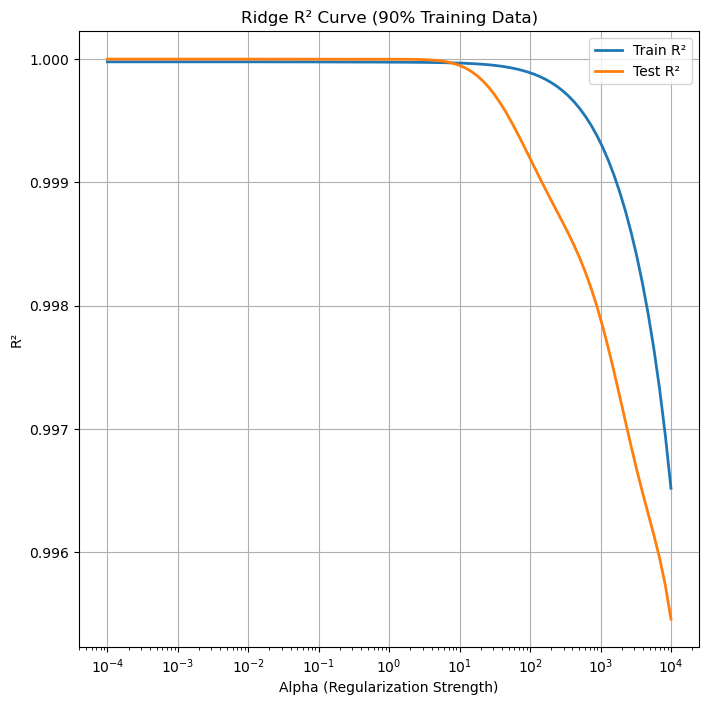

selected Alpha = 0.00012045035402587823
train R² at stable region = 0.999977806060513

Results
----------------------------------------
Train MSE : 0.0143
Train R²  : 1.0000
Train RMSE : 0.1194
Test MSE  : 0.0005
Test R²   : 1.0000
Test RMSE  : 0.0221
Train std: 25.346093586232445
Test std : 76.10459743243425


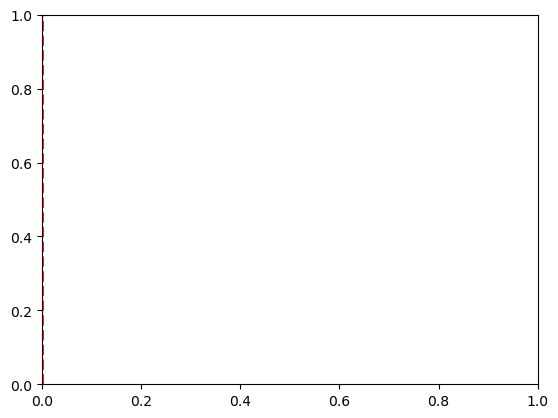

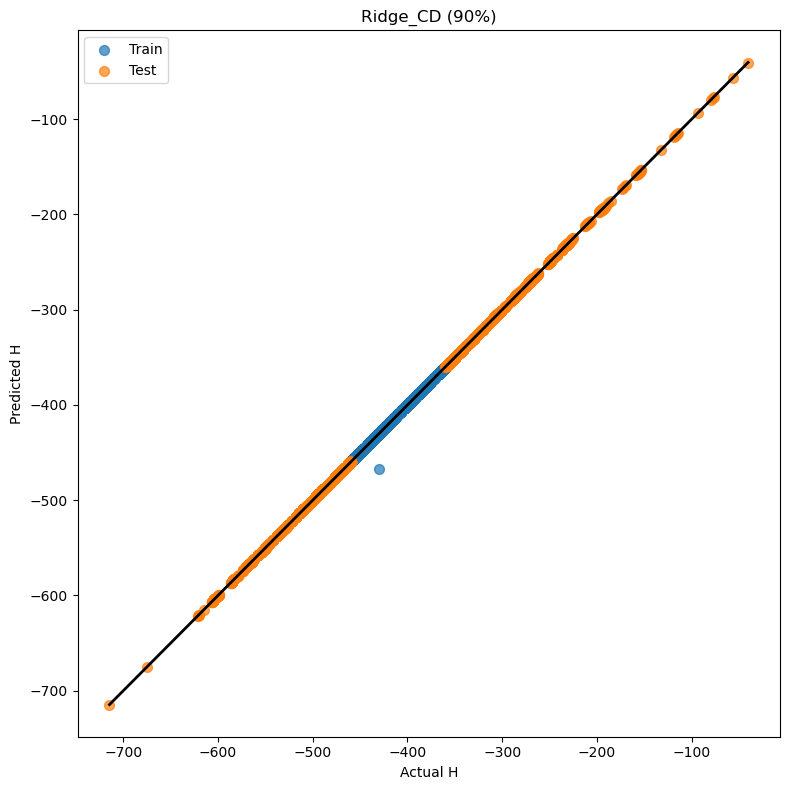

In [3]:
############################################################
# CHEMICAL DESCRIPTOR-RIDGE REGRESSION
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Descriptors

descriptor_names = [name for name, func in Descriptors.descList]
print("Total Descriptors:", len(Descriptors.descList))
# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"].values
y = data["H"].values
print("Started")
# ===============================
# CHEMICAL DESCRIPTOR(WITHOUT FEATURE SELECTION)
# ===============================
descriptor_values = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        values = [func(mol) for name,func in Descriptors.descList]
    else:
        values = [np.nan]*len(descriptor_names)
    descriptor_values.append(values)
X_df = pd.DataFrame(descriptor_values, columns=descriptor_names)
print("success")

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X_df[train_mask]
y_train_full = y[train_mask]

X_test_all = X_df[test_mask]
y_test_all = y[test_mask]
print("Train H range:", y_train_full.min(), y_train_full.max())
print("Test H range :", y_test_all.min(), y_test_all.max())

print("Train samples:", len(y_train_full))
print("Test samples :", len(y_test_all))

# ===============================
# FIX TEST SET TO 24,869 SAMPLES
# ===============================

np.random.seed(42)

test_indices = np.random.choice(
    len(X_test_all),
    size=24869,
    replace=False
)

X_test = X_test_all.iloc[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Samples:", len(X_test))

# ===============================
# TRAINING FRACTIONS
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

# Alpha values (iterations equivalent)
alpha_values = np.logspace(-4, 4, 100)

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )

    X_train_sub = X_train_full.iloc[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    # ===============================
    # SCALING
    # ===============================

    x_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_sub)
    X_test_scaled = x_scaler.transform(X_test)
    
    # ===============================
    # RIDGE REGRESSION
    # ===============================

    train_r2_list = []
    test_r2_list = []

    for alpha in alpha_values:

        ridge = Ridge(alpha=alpha)

        ridge.fit(X_train_scaled, y_train_sub)

        y_pred_train_iter = ridge.predict(X_train_scaled)
        y_pred_test_iter = ridge.predict(X_test_scaled)

        train_r2 = r2_score(y_train_sub, y_pred_train_iter)
        test_r2 = r2_score(y_test, y_pred_test_iter)

        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)

    # ===============================
    # PLOT R² vs ALPHA
    # ===============================

    plt.figure(figsize=(8,8))

    plt.plot(
        alpha_values,
        train_r2_list,
        label='Train R²',
        linewidth=2
    )

    plt.plot(
        alpha_values,
        test_r2_list,
        label='Test R²',
        linewidth=2
    )

    plt.xscale('log')

    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('R²')
    plt.title(f'Ridge R² Curve ({int(frac*100)}% Training Data)')
    plt.legend()
    plt.grid(True)

    plt.show()

    # ===============================
    # STABLE ALPHA VALUE
    # ===============================
    train_r2_array = np.array(train_r2_list)
    impovement = np.abs(np.diff(train_r2_array))
    thershold = 1e-4
    stable_indices = np.where(impovement<thershold)[0]
    if len(stable_indices) > 0:
        stable_start = stable_indices[0] + 1
        best_alpha = alpha_values[stable_start]
    else:
        best_alpha = alpha_values[np.argmax(train_r2_array)]
        
    best_r2 = train_r2_array[stable_start] if len(stable_indices) > 0 else np.max(train_r2_array)
    print("selected Alpha =", best_alpha)
    print("train R² at stable region =", best_r2)

    plt.axvline(best_alpha,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Selected α={best_alpha:.4f}')

    # ===============================
    # FINAL MODEL USING BEST ALPHA
    # ===============================

    ridge = Ridge(alpha=best_alpha)

    ridge.fit(X_train_scaled, y_train_sub)

    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE  : {rmse_test:.4f}")
    print("Train std:", np.std(y_train_sub))
    print("Test std :", np.std(y_test))


    # ===============================
    # PARITY PLOT
    # ===============================
    plt.figure(figsize=(8,8))

    # Train points
    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.7,
        label='Train'
    )

    # Test points
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.7,
        label='Test'
    )

    # Determine limits using both train and test
    min_val = min(
        y_train_sub.min(),
        y_pred_train.min(),
        y_test.min(),
        y_pred_test.min()
    )

    max_val = max(
        y_train_sub.max(),
        y_pred_train.max(),
        y_test.max(),
        y_pred_test.max()
    )

    # x = y reference line
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'k-',
        linewidth=2,
    )

    plt.xlabel('Actual H')
    plt.ylabel('Predicted H')
    plt.title(f'Ridge_CD ({int(frac*100)}%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"CD_RR_Parity_{int(frac*100)}.png",
        dpi=600,
        bbox_inches='tight'
    )
    plt.show()